Author: Sabina Gallo  
ID: 535785  
Academic Year: 2025/2026  
Course: AI for Communication and Marketing

# **From Churn Prediction to Retention Strategy: A Propensity Model for E-commerce Customer Relationship Management**

# **Business Context**  
The Marketing department of a leading e-commerce platform is concerned about customer retention. The company has access to customer profile data, satisfaction signals, complaint information, digital engagement variables and transaction summaries. The objective of this project is to build a churn propensity model able to identify customers who are at risk of leaving and to translate the model output into actionable marketing recommendations.

In an e-commerce context, churn does not simply mean that a customer disappears. It may reflect different customer situations, such as low satisfaction, reduced digital engagement, delivery friction, price sensitivity, recent complaints, weak relationship maturity or a long period without orders. For this reason, the model is used not only as a classification tool, but also as a prioritization system for retention marketing.

The target variable is **"Churn"**. A value of 1 identifies customers who are classified as churners or customers already showing churner behaviour, while a value of 0 identifies customers who are currently retained. The model will estimate the **probability that each customer belongs to the churn class**, so that the Marketing department can decide who should be contacted first, which risk drivers should be addressed and what type of retention action should be activated.

From a business perspective, false negatives are particularly costly because they represent real churners who are not detected and therefore do not receive any retention action. False positives are less severe because they manily represent loyal customers who may receive an unnecessary communication or incentive. For this reason, model evaluation will pay particular attention to recall, F1-score and lift, rather than relying only on accuracy.

The project follows four main phases: data audit and quality assessment, exploratory analysis of churn-related behavioural and satisfaction signals, propensity modeling with baseline comparison and lift evaluation and the translation of churn probabilities into a **Risk x Value** framework and targeted communication recommendations.

## **Data Audit and Quality Assessment**

The first step is to audit the dataset before building any predictive model. In a churn propensity project, data quality is directly connected to the reliability of the final marketing decisions: missing values, inconsistent records or outliers could distort the estimated churn probabilities and lead the company to target the wrong customers.

This section therefore checks the structure of the customer base, the presence of missing values, duplicates, inconsistent values and potential outliers. The objective is to prepare a reliable analytical dataset while preserving the customer-level information needed for retention analysis.

In [78]:
# Import the main libraries for data manipulation, visualization and modeling

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone 

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, cross_val_predict



from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")

# Set display options for easier inspection
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

In [79]:
# Load the dataset
df = pd.read_excel("data.xlsx")

# Display the first rows
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001.000,1,4.000,Mobile Phone,3,6.000,Debit Card,Female,3.000,3,Laptop & Accessory,2,Single,9,1,11.000,1.000,1.000,5.000,159.930
1,50002.000,1,NaN,Phone,1,8.000,UPI,Male,3.000,4,Mobile,3,Single,7,1,15.000,0.000,1.000,0.000,120.900
2,50003.000,1,NaN,Phone,1,30.000,Debit Card,Male,2.000,4,Mobile,3,Single,6,1,14.000,0.000,1.000,3.000,120.280
3,50004.000,1,0.000,Phone,3,15.000,Debit Card,Male,2.000,4,Laptop & Accessory,5,Single,8,0,23.000,0.000,1.000,3.000,134.070
4,50005.000,1,0.000,Phone,1,12.000,CC,Male,NaN,3,Mobile,5,Single,3,0,11.000,1.000,1.000,3.000,129.600


In [80]:
df.shape

(5630, 20)

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5628 non-null   float64
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5628 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

The dataset contains 5630 customer-level observations and 20 variables. This structure is appropriate for a churn propensity model because each row represents one customer who can receive an individual churn probability score.

The variables combine customer profile information, digital engagement, transactional behavior and customer experience signals. This is useful because churn can be influenced not only by purchases, but also by satisfaction, complaints, app usage, recency and promotional behavior.

The target variable **Churn** has no missing values, while "CustomerID" is only an identifier and will be exlcuded from the predictive features. Some relevant behavioural and transactional variables, such as "Tenure", "WarehousetoHome", "HourSpendOnApp", "CouponUsed", "OrderCount" and "DaySinceLastOrder", contain missing values. These will be handled through preprocessing rather than aggressive row deletion, in order to preserve the customer base and avoid losing potentially useful churn-related signals.

In [82]:
# Summary statistics for numerical variables
df.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
CustomerID,5628.000000,52814.549041,1624.890759,50001.000000,51407.750000,52814.500000,54221.250000,55630.000000
Churn,5630.000000,0.168384,0.374240,0.000000,0.000000,0.000000,0.000000,1.000000
Tenure,5366.000000,10.189899,8.557241,0.000000,2.000000,9.000000,16.000000,61.000000
CityTier,5630.000000,1.654707,0.915389,1.000000,1.000000,1.000000,3.000000,3.000000
WarehouseToHome,5379.000000,15.639896,8.531475,5.000000,9.000000,14.000000,20.000000,127.000000
HourSpendOnApp,5375.000000,2.931535,0.721926,0.000000,2.000000,3.000000,3.000000,5.000000
NumberOfDeviceRegistered,5630.000000,3.688988,1.023999,1.000000,3.000000,4.000000,4.000000,6.000000
SatisfactionScore,5630.000000,3.066785,1.380194,1.000000,2.000000,3.000000,4.000000,5.000000
NumberOfAddress,5630.000000,4.214032,2.583586,1.000000,2.000000,3.000000,6.000000,22.000000
Complain,5630.000000,0.284902,0.451408,0.000000,0.000000,0.000000,1.000000,1.000000


The numerical summary confirms that the target is imbalanced: the mean of "Churn" is approximately 0.168, meaning that churners represent about 16.8% of the customer base. This will be important during model evaluation, where recall, F1-score and lift will be more informative than accuracy alone.

The ranges of "Tenure", "DaySinceLAstOrder", "OrderCount", "CouponUsed" and "HourSpendOnApp" provide useful behavioural signals related to relationship maturity, recency, purchase intensity, promotional behaviour and digital engagement.

The summary also highlights two potential consistency issues: "WarehouseToHome" reaches 127 despite a median of 14 and "CashbackAmount" reaches 999999 despite a median around 163. These values will be examined later in the outlier audit before defining the final preprocessing strategy.

In [83]:
# Summary statistics for categorical variables
df.describe(include="object").T.style.background_gradient(cmap='Oranges', axis=1)

,count,unique,top,freq
PreferredLoginDevice,5630,4,Mobile Phone,2763
PreferredPaymentMode,5630,7,Debit Card,2314
Gender,5628,2,Male,3383
PreferedOrderCat,5630,6,Laptop & Accessory,2050
MaritalStatus,5630,4,Married,2984


The dataset includes five categorical variables describing device prefernece, payment behaviour, gender, preferred order category and marital status. These variables are relevant because they capture how customers access the platform, how they pay and what type of products they usually buy.

"PreferredLoginDevice", "PreferredPaymentMOde" and "PreferedOrderCat" show multiple categories, with "MobilePhone", "Debit Card" and "Lapotop & Accessory" as the most frequent values. Before encoding, these variables will need a consistency check to verify similar labels, such as abbreviated and extended payment or device names, should be standardized.

In [84]:
# Rename columns with spelling issues for readability
df = df.rename(columns={
    "PreferedOrderCat": "PreferredOrderCat"
})

# Check updated column names
df.columns.tolist()

['CustomerID',
 'Churn',
 'Tenure',
 'PreferredLoginDevice',
 'CityTier',
 'WarehouseToHome',
 'PreferredPaymentMode',
 'Gender',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'PreferredOrderCat',
 'SatisfactionScore',
 'MaritalStatus',
 'NumberOfAddress',
 'Complain',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

The column **"PreferedOrderCat"** is renamed as "PreferredOrderCat" to correct a spelling issue and improve readability. This adjustment only changes the column name and does not modify the information contained in the variable.

### **Variable grouping and marketing interpretation**

| Business area | Variables | Marketing interpretation |
|---|---|---|
| Customer identification | `CustomerID` | Technical identifier used to distinguish individual customers. It supports data auditing and record-level checks but is excluded from the predictive feature set because it does not represent customer behaviour. |
| Target variable | `Churn` | Binary outcome of the project. `Churn = 1` identifies customers who churned, while `Churn = 0` identifies customers who were retained. |
| Customer profile and market context | `Gender`, `MaritalStatus`, `CityTier` | Describes relatively stable customer characteristics and the market context in which the customer operates. These variables may help identify differences in churn patterns across customer groups, but they should not be interpreted as direct causes of churn. |
| Relationship maturity | `Tenure` | Measures how long the customer has maintained a relationship with the company. Shorter tenure may indicate a more fragile early-stage relationship, while longer tenure may reflect greater familiarity and accumulated loyalty. |
| Digital engagement | `PreferredLoginDevice`, `HourSpendOnApp` | Captures how customers access and interact with the e-commerce platform. Lower platform engagement or device-specific usage patterns may indicate weaker relationship intensity. |
| Device and account complexity | `NumberOfDeviceRegistered`, `NumberOfAddress` | Represents the complexity of the customer’s digital and account configuration. A larger number of registered devices or addresses may be associated with different service needs, usage patterns or friction points. |
| Purchase activity | `OrderCount`, `OrderAmountHikeFromlastYear` | Describes purchasing intensity and changes in order value over time. These variables help distinguish active customers from customers whose commercial relationship may be weakening. |
| Promotional and reward behaviour | `CouponUsed`, `CashbackAmount` | Captures customers’ exposure and responsiveness to promotional incentives. Strong reliance on coupons or cashback may indicate price sensitivity and can inform the design of retention offers. |
| Purchase recency | `DaySinceLastOrder` | Measures the time elapsed since the customer’s most recent purchase. Longer inactivity may indicate declining engagement and a greater need for reactivation communication. |
| Customer experience and service friction | `SatisfactionScore`, `Complain`, `WarehouseToHome` | Captures satisfaction, complaint history and potential logistic inconvenience. These variables help explain the experience-related conditions associated with churn risk, rather than only identifying who is likely to churn. |
| Commercial preferences | `PreferredOrderCat`, `PreferredPaymentMode` | Describes preferred product categories and payment methods. These variables support customer-level interpretation and can later guide the personalization of retention messages and offers. |

The variable grouping shows that the dataset contains a balanced mix of customer profile, digital engagmenet, transactional, experience-related and commercial preference variables. This is useful for a churn propensity model because customer churn is not interpreted only as a purchase outcome, but as the result of multiple relationship signals: how long the customer has been connected to the company, how actively they use the platform, how recently they ordered, whether they complained and what type of commercial behaviour they show. 

This structure also supports the final marketing objective of the project: predicted churn probabilities can later be interpreted through concrete business dimensions and translated into targeted retention actions.

### **Preliminary Categorical Cleaning**
Before quantifying missing values, categorical variables are checked for leading or trailing spaces and textual placeholders. The value N.A. in PreferredLoginDevice does not represent a genuine login-device category and is therefore converted into an actual missing value. This ensures that it is correctly included in the missing-value audit and later handled by the categorical preprocessing pipeline.

In [85]:
# Remove leading and trailing spaces from categorical values
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].str.strip()

# Convert the textual placeholder into a real missing value
df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({
    "N.A.": np.nan
})

### **Missing Values Audit**

After the initial inspection, the next step is to quantify missing values more precisely. This is important because several variables with missing observations are not secondary fields: they describe customer recency, tenure, order activity, coupon usage, app engagement and logistic distance.

In a churn propensity model, these dimensions can directly affect the estimated probability of churn. Therefore, the goal of this audit is not only to count missing values, but also to decide whether the missingness affects variables that are strategically relevant for customer retention and marketing activation.

In [86]:
# Calculate missing values for each variable
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

# Keep only variables with at least one missing value and sort them
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary = missing_summary.sort_values(by="missing_percentage", ascending=False)

missing_summary

,missing_count,missing_percentage
DaySinceLastOrder,307,5.450
OrderAmountHikeFromlastYear,265,4.710
Tenure,264,4.690
OrderCount,258,4.580
CouponUsed,256,4.550
HourSpendOnApp,255,4.530
WarehouseToHome,251,4.460
PreferredLoginDevice,5,0.090
CustomerID,2,0.040
Gender,2,0.040


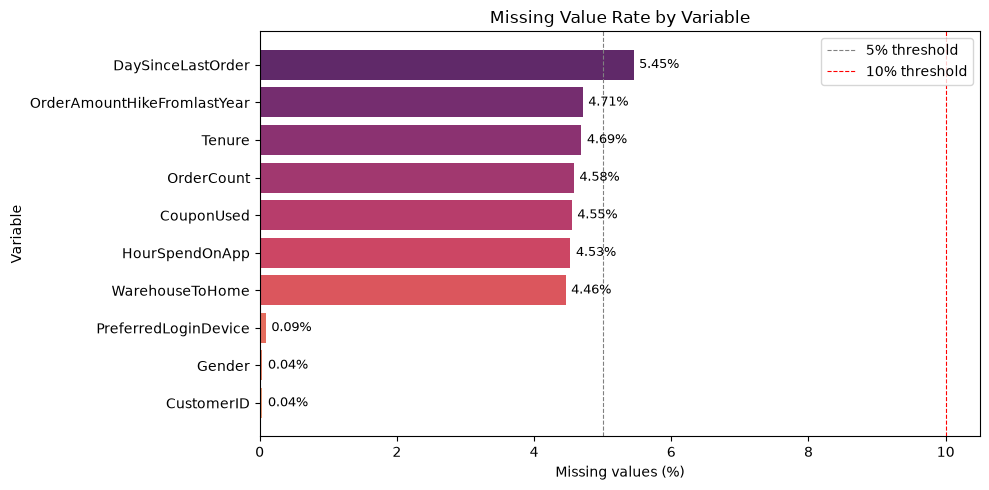

In [87]:
# Visualize missing value percentage by variable
missing_plot = missing_summary.sort_values("missing_percentage", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    missing_plot.index,
    missing_plot["missing_percentage"],
    color=sns.color_palette("flare", len(missing_plot))
)

ax.axvline(5, color="grey", linestyle="--", linewidth=0.8, label="5% threshold")
ax.axvline(10, color="red", linestyle="--", linewidth=0.8, label="10% threshold")

ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Variable")
ax.set_title("Missing Value Rate by Variable")
ax.legend()

for bar, pct in zip(bars, missing_plot["missing_percentage"]):
    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.2f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [88]:
# Inspect records with missing CustomerID
df[df["CustomerID"].isna()].T

,5457,5524
CustomerID,NaN,NaN
Churn,1,0
Tenure,1.000,2.000
PreferredLoginDevice,Phone,Computer
CityTier,2,3
WarehouseToHome,27.000,8.000
PreferredPaymentMode,Credit Card,Debit Card
Gender,Female,Male
HourSpendOnApp,4.000,3.000
NumberOfDeviceRegistered,4,5


In [89]:
# Inspect records with missing Gender
df[df["Gender"].isna()].T

,2189,2190
CustomerID,52190.000,52191.000
Churn,0,0
Tenure,3.000,13.000
PreferredLoginDevice,Mobile Phone,Computer
CityTier,3,1
WarehouseToHome,16.000,32.000
PreferredPaymentMode,E wallet,Credit Card
Gender,NaN,NaN
HourSpendOnApp,3.000,3.000
NumberOfDeviceRegistered,4,4


In [90]:
# Remove records without a customer identifier
# These observations cannot be connected to an actionable retention campaign
df = df.dropna(subset=["CustomerID"]).copy()

# CustomerID is an identifier rather than a numerical measurement
df["CustomerID"] = df["CustomerID"].astype("int64")

# Verify the updated dataset
print("Updated dataset shape:", df.shape)
print("Missing CustomerID values:", df["CustomerID"].isna().sum())

Updated dataset shape: (5628, 20)
Missing CustomerID values: 0


The missing values are concentrated in a limited group of variables. The highest missing percentage is observed for "DaySinceLastOrder", with 307 missing values, equal to 5.45% of the dataset. This is the only variable slightly above the 5% reference threshold, while all other main affected variables remain below 5%. No variable exceeds the 10% threshold.  

The affected variables are not secondary fields: "DaySinceLastOrder", "Tenure", "OrderCount", "CouponUsed", "HourSpendOnApp" and "WarehouseToHome" describe recency, relationshp maturity, purchase intensity, promotional behavior, digital engagement and logistic distance. These dimensions are direclty connected to churn risk and can support later marketing interpretation.

The two observations with missing CustomerID were inspected and did not present structural problems. However, they were removed because a churn prediction without a customer identifier cannot be connected to an actionable retention campaign. Since these records represent only 0.04% of the original dataset, their removal has a negligible effect on the analytical sample.

The two observations with missing Gender are retained because the remaining customer information is complete and potentially useful for churn prediction. Gender will be imputed with the most frequent category inside the preprocessing pipeline. Performing imputation within the pipeline ensures that the replacement value is estimated using only the training data and therefore avoids information leakage.

For the numerical variables with missing values, the preferred strategy is imputation rather than row deletion. Median imputation will be used inside the preprocessing pipeline, because these variables may be skewed and affected by outliers. This preserves the customer base while avoiding information leakage from the test set.

### **Duplicate Records and Customer ID Consistency**

This check verifies whther the customer-level structure of the datset is reliable. In a churn propensity model, duplicated rows or duplicated customer identifiers could distort the churn rate and give the model repeated information about the same customer.

For this reason, the audit checks both fully duplicated rows and duplicated "CustomerID" values, while taking into account that customer identifiers are missing.

In [91]:
# Check for fully duplicated rows
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


In [92]:
# Compare valid unique customer identifiers with the total number of rows
df["CustomerID"].nunique(), df.shape[0]

(5628, 5628)

In [93]:
# Check duplicated CustomerID values excluding missing identifiers
print("Duplicated CustomerID values excluding missing IDs:", df["CustomerID"].dropna().duplicated().sum())

Duplicated CustomerID values excluding missing IDs: 0


There are no fully duplicated rows and no duplicated customer identifiers. After removing the two observations without a usable customer identifier, the number of unique CustomerID values matches the total number of rows.

This confirms that the dataset is correctly structured at customer level: each remaining row corresponds to one uniquely identifiable customer. Therefore, no additional duplicate removal is required before building the churn propensity model.

### **Categorical Consistency Audit**

This section checks whther categorical variables contain inconsistent labels before encoding them for machine learning. In a churn model, equivalent customer behaviors should not be split into different categories only because they are written in different formats.

This is especially important for variables such as "PreferredLoginDevice" and "PreferredPaymentMode", because device and payment preferences can later be interpreted as digital journey and transaction behavior signals.

In [94]:
# Inspect unique values for categorical variables
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


PreferredLoginDevice
PreferredLoginDevice
Mobile Phone    2763
Computer        1631
Phone           1229
NaN                5
Name: count, dtype: int64

PreferredPaymentMode
PreferredPaymentMode
Debit Card          2313
Credit Card         1500
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender
Gender
Male      3382
Female    2244
NaN          2
Name: count, dtype: int64

PreferredOrderCat
PreferredOrderCat
Laptop & Accessory    2049
Mobile Phone          1270
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     2982
Single      1795
Divorced     848
Widow          3
Name: count, dtype: int64


In [95]:
# Standardize semantically equivalent categorical labels
df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({
    "Phone": "Mobile Phone"
})

df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({
    "CC": "Credit Card",
    "COD": "Cash on Delivery"
})

df["PreferredOrderCat"] = df["PreferredOrderCat"].replace({
    "Mobile": "Mobile Phone"
})

# Verify the corrected category distributions
for col in [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "PreferredOrderCat"
]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


PreferredLoginDevice
PreferredLoginDevice
Mobile Phone    3992
Computer        1631
NaN                5
Name: count, dtype: int64

PreferredPaymentMode
PreferredPaymentMode
Debit Card          2313
Credit Card         1773
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

PreferredOrderCat
PreferredOrderCat
Mobile Phone          2079
Laptop & Accessory    2049
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64


The categorical consistency audit identified several labels representing the same underlying customer behaviour. In PreferredLoginDevice, Phone was merged with Mobile Phone. In PreferredPaymentMode, CC was standardized as Credit Card, while COD was merged with Cash on Delivery. In PreferredOrderCat, Mobile was standardized as Mobile Phone.

The textual placeholder N.A. in PreferredLoginDevice had already been converted into an actual missing value before the missing-value audit. These corrections prevent equivalent customer behaviours from being encoded as separate categories and improve both model reliability and business interpretability.

### **Numerical Consistency**

This section checks whether numerical variables contain impossible values or extreme observations that could distort the churn propensity model. The focus is not to remove unusual values automatically, but to distinguish between plausible rare customer behaviors and values that are likely to be data entry errors.

This is especially important for variables such as WarehouseToHome, Tenure, DaySinceLastOrder and CashbackAmount, because they describe logistic distance, relationship maturity, recency and customer incentives.

In [96]:
# Check minimum and maximum values for numerical variables
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

range_summary = pd.DataFrame({
    "min": df[numerical_columns].min(),
    "max": df[numerical_columns].max(),
    "median": df[numerical_columns].median(),
    "mean": df[numerical_columns].mean()
})

range_summary

,min,max,median,mean
CustomerID,50001.000,55630.000,52814.500,52814.549
Churn,0.000,1.000,0.000,0.168
Tenure,0.000,61.000,9.000,10.193
CityTier,1.000,3.000,1.000,1.654
WarehouseToHome,5.000,127.000,14.000,15.639
HourSpendOnApp,0.000,5.000,3.000,2.931
NumberOfDeviceRegistered,1.000,6.000,4.000,3.689
SatisfactionScore,1.000,5.000,3.000,3.067
NumberOfAddress,1.000,22.000,3.000,4.215
Complain,0.000,1.000,0.000,0.285


The numerical range summary does not show impossible negative values in the main behavioral variables. "Tenure", "WarehouseToHome", "HourSpendOnApp", "DaySinceLastOrder", "OrderCount" and "Coupon"used" all have minimum values that are compatible with the meaning of the variables.

However, two values require further inspection. "WarehouseToHome" reaches a maximum of 126, compared with a median of 14, suggesting a possible logistic distance outlier. More importantly, "CashbackAmount" reaches 999999, while its median is around 163. This value is clearly outside the scale of the variable and needs to be investigated before modeling.

In [97]:
# Inspect extremely high CashbackAmount values
df.sort_values("CashbackAmount", ascending=False).head(10).T

,5518,590,2880,4350,3436,4906,5011,3541,2855,4325
CustomerID,55519,50591,52881,54351,53437,54907,55012,53542,52856,54326
Churn,0,0,0,0,0,0,0,0,0,0
Tenure,5.000,6.000,26.000,26.000,15.000,15.000,30.000,30.000,24.000,24.000
PreferredLoginDevice,Mobile Phone,Computer,Mobile Phone,Mobile Phone,Computer,Computer,Mobile Phone,Mobile Phone,Mobile Phone,Mobile Phone
CityTier,3,1,1,1,1,1,1,1,1,1
WarehouseToHome,17.000,6.000,7.000,7.000,14.000,14.000,11.000,11.000,18.000,18.000
PreferredPaymentMode,Credit Card,UPI,Debit Card,Debit Card,Debit Card,Debit Card,Cash on Delivery,Cash on Delivery,Debit Card,Debit Card
Gender,Female,Female,Male,Male,Female,Female,Female,Female,Female,Female
HourSpendOnApp,3.000,2.000,4.000,4.000,3.000,3.000,4.000,4.000,3.000,3.000
NumberOfDeviceRegistered,4,1,5,5,6,6,4,4,4,4


In [98]:
# Count clearly invalid CashbackAmount values
invalid_cashback_count = (df["CashbackAmount"] == 999999).sum()
invalid_cashback_count

np.int64(2)

In [99]:
# Replace clearly invalid CashbackAmount values with NaN
df.loc[df["CashbackAmount"] == 999999, "CashbackAmount"] = np.nan

# Check the updated maximum value
df["CashbackAmount"].max()

np.float64(324.99)

The two **"CashbackAmount"** values equal to 999999 were treated as a data entry errors and replaced with missing values. The affected rows were kept because the customers still contain useful churn-related information in the other variables.

After the correction, the maximum valid value becomes 324.99, which is consistent with the observed scale of the remaining distribution.The new missing values will be handled later through median imputation inside the preprocessing pipeline.

In addition, **"WarehouseToHome"** contains two very high values, 126 and 127, while the median distance is 14 and the next highest observations are around 36.

In [100]:
# Inspect extremely high WarehouseToHome values
df.sort_values("WarehouseToHome", ascending=False).head(10).T

,4124,1309,4431,4221,4984,4620,3042,5484,3115,2889
CustomerID,54125,51310,54432,54222,54985,54621,53043,55485,53116,52890
Churn,0,0,1,0,0,0,0,0,0,0
Tenure,26.000,25.000,11.000,12.000,16.000,1.000,22.000,3.000,24.000,12.000
PreferredLoginDevice,Computer,Computer,Computer,Computer,Mobile Phone,Mobile Phone,Mobile Phone,Mobile Phone,Mobile Phone,Mobile Phone
CityTier,3,3,1,1,1,3,3,1,1,1
WarehouseToHome,127.000,126.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000
PreferredPaymentMode,Debit Card,Debit Card,Debit Card,Debit Card,Credit Card,Credit Card,Credit Card,Debit Card,Debit Card,Cash on Delivery
Gender,Male,Male,Male,Female,Male,Male,Female,Male,Male,Male
HourSpendOnApp,3.000,2.000,3.000,3.000,3.000,3.000,4.000,4.000,3.000,3.000
NumberOfDeviceRegistered,4,3,4,4,6,4,4,6,5,4


In [101]:
# Count very high WarehouseToHome values
high_warehouse_count = (df["WarehouseToHome"] > 50).sum()
high_warehouse_count

np.int64(2)

Unlike the invalid "CashbackAmount" values, these distances are not impossible: they may represent rare customers living very far from the warehouse. For this reason, they are not replaced with missing values.

However, they will be considered for capping during preprocessing to reduce their influence on scale-sensitive models while preserving the customer records.

### **Logical Consistency Checks**

Before applying a statistical outlier method, the numerical variables are checked against basic business logic. This step verifies whether binary variables contain only valid classes, whether satisfaction and city-tier scores stay within their expected ranges and whether behavioral variables such as tenure, order count, coupon usage, recency and app usage contain impossible negative values.

This distinction is important because not all unusual values are errors. Some values may be rare but valid customer behaviors, while others may violate the meaning of the variable and require correction before modeling.



In [102]:
# Logical consistency checks for bounded and non-negative variables

logical_checks = {
    "Churn valid values": df["Churn"].dropna().isin([0, 1]).all(),
    "Complain valid values": df["Complain"].dropna().isin([0, 1]).all(),
    "CityTier valid range": df["CityTier"].dropna().between(1, 3).all(),
    "SatisfactionScore valid range": df["SatisfactionScore"].dropna().between(1, 5).all(),
    "No negative Tenure": (df["Tenure"].dropna() >= 0).all(),
    "No negative WarehouseToHome": (df["WarehouseToHome"].dropna() >= 0).all(),
    "No negative HourSpendOnApp": (df["HourSpendOnApp"].dropna() >= 0).all(),
    "No negative OrderCount": (df["OrderCount"].dropna() >= 0).all(),
    "No negative CouponUsed": (df["CouponUsed"].dropna() >= 0).all(),
    "No negative DaySinceLastOrder": (df["DaySinceLastOrder"].dropna() >= 0).all(),
    "No negative CashbackAmount": (df["CashbackAmount"].dropna() >= 0).all()
}

logical_checks = pd.DataFrame.from_dict(
    logical_checks,
    orient="index",
    columns=["check_passed"]
)

logical_checks

,check_passed
Churn valid values,True
Complain valid values,True
CityTier valid range,True
SatisfactionScore valid range,True
No negative Tenure,True
No negative WarehouseToHome,True
No negative HourSpendOnApp,True
No negative OrderCount,True
No negative CouponUsed,True
No negative DaySinceLastOrder,True


All logical consistency checks are passed. The binary variables "Churn" and "Complain" contain only valid values, while "CityTier" and "SatisfactionScore" remain within their expected ranges.

The main behavioral and transactional variables also contain no negative values. This means that variables such as "Tenure", "WarehouseToHome", "HourSpendOnApp", "OrderCount", "CouponUsed", "DaySinceLastOrder" and "CashbackAmount" are logically valid after the correction of the invalid cashback values.

The remaining issue is therefore not impossible values, but the presence of extreme values that may still affect some models. For this reason, the next step applies an IQR-based outlier detection.

### **Outlier Detection**

The IQR method is used as a diagnostic tool to identify variables with statistically extreme values. These values will not be removed automatically, because in a churn context they may represent meaningful but uncommon customer behaviors.

In [103]:
# Detect outliers using the IQR method for selected numerical variables
outlier_columns = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

outlier_summary = []

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append({
        "variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outliers.shape[0],
        "outlier_percentage": round(outliers.shape[0] / df.shape[0] * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary.sort_values("outlier_percentage", ascending=False)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
7,OrderCount,1.000,3.000,2.000,-2.000,6.000,703,12.490
6,CouponUsed,1.000,2.000,1.000,-0.500,3.500,629,11.180
9,CashbackAmount,145.755,196.400,50.645,69.787,272.368,438,7.780
3,NumberOfDeviceRegistered,3.000,4.000,1.000,1.500,5.500,397,7.050
8,DaySinceLastOrder,2.000,7.000,5.000,-5.500,14.500,62,1.100
5,OrderAmountHikeFromlastYear,13.000,18.000,5.000,5.500,25.500,33,0.590
2,HourSpendOnApp,2.000,3.000,1.000,0.500,4.500,6,0.110
0,Tenure,2.000,16.000,14.000,-19.000,37.000,4,0.070
4,NumberOfAddress,2.000,6.000,4.000,-4.000,12.000,4,0.070
1,WarehouseToHome,9.000,20.000,11.000,-7.500,36.500,2,0.040


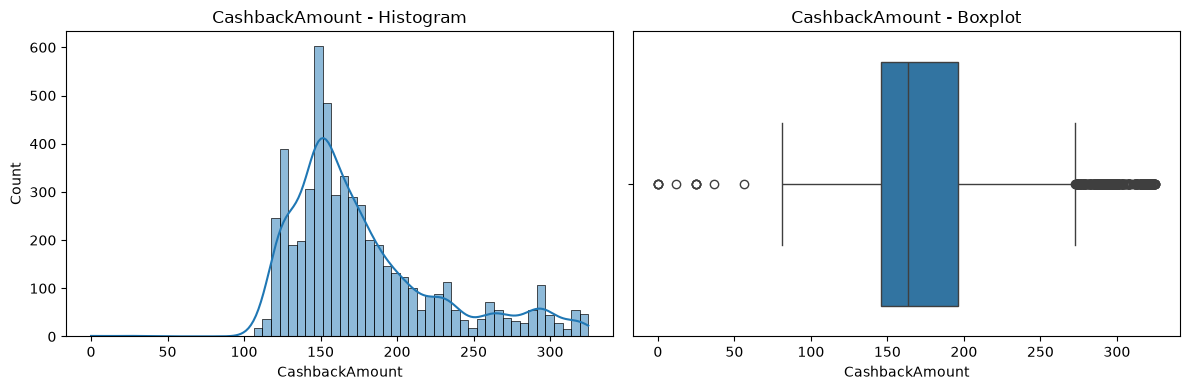

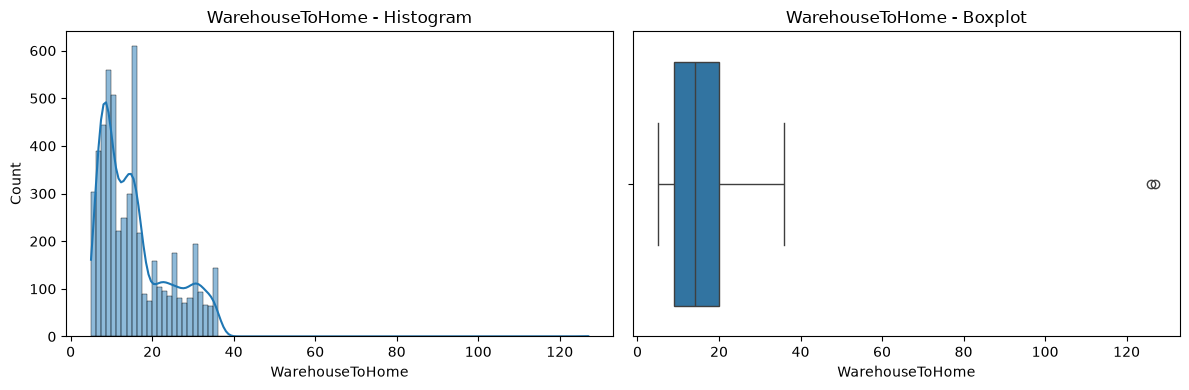

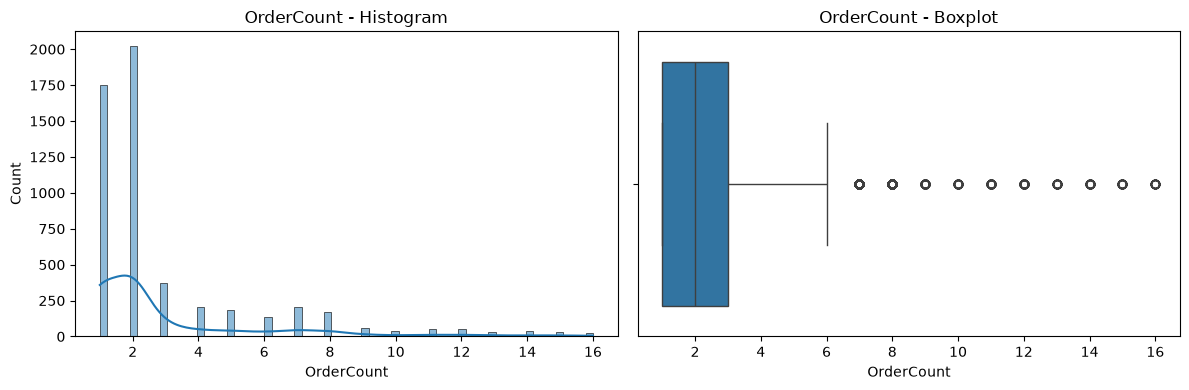

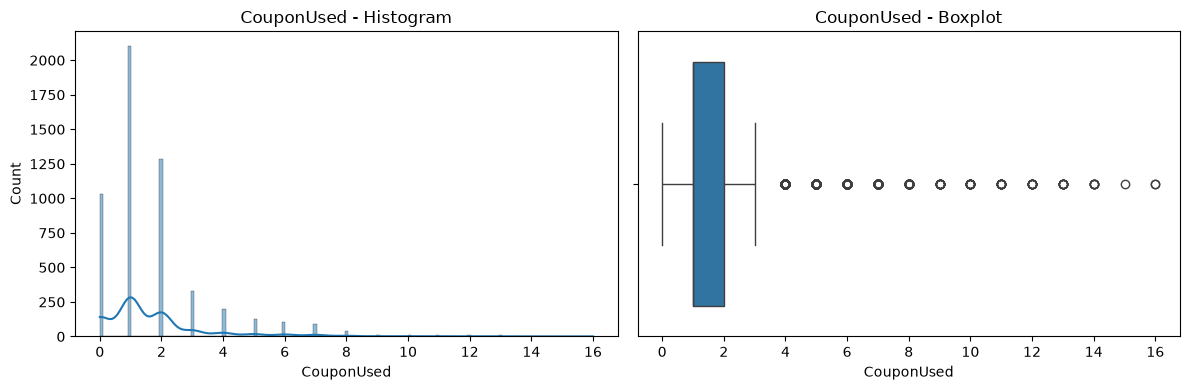

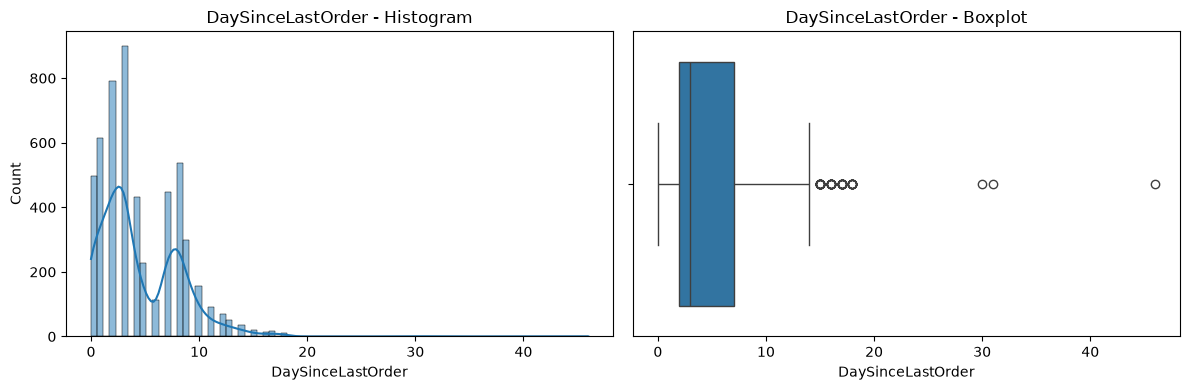

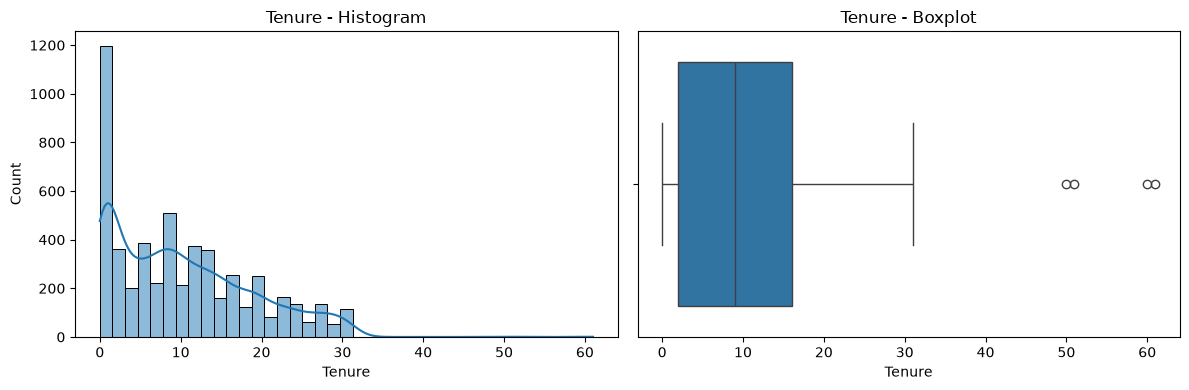

In [104]:
variables_to_plot = [
    "CashbackAmount",
    "WarehouseToHome",
    "OrderCount",
    "CouponUsed",
    "DaySinceLastOrder",
    "Tenure"
]

for col in variables_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"{col} - Histogram")
    axes[0].set_xlabel(col)
    
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"{col} - Boxplot")
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

The visual inspection confirms that the outliers have different meanings across variables.    
```CashbackAmount``` now shows a realistic right-skewed distribution after removing the invalid 999999 values. The remaining high cashback values are concentrated around the upper tail of the distribution and appear consistent with highly rewarded customers rather than data entry errors.

```WarehouseToHome``` shows a different pattern: most customers live relatively close to the warehouse, while only two observations are isolated at very high distances. These two cases are extreme but still plausible logistic-distance situations, so they are preserved and considered for later capping.

```OrderCount``` and ```CouponUsed``` are strongly right-skewed. Most customers place few orders and use few coupons, while a smaller group shows much higher activity or promotional responsiveness. These values are meaningful for churn modeling because they may identify engaged or price-sensitive customers.

```DaySinceLastOrder``` also shows a right tail, which is important from a retention perspective because longer inactivity can indicate behavioral disengagement. ```Tenure``` includes a small number of very long-standing customers, but these values are not impossible and may capture relationship maturity.

Overall, the visual audit supports a conservative treatment strategy. Invalid values are corrected, while plausible extreme customer behaviours are retained. The two exceptionally large WarehouseToHome observations will be handled within the training preprocessing rather than removed, so their influence on scale-sensitive models can be reduced without losing the corresponding customers. The remaining IQR outliers are retained because they primarily reflect valid behavioural skewness rather than data-entry errors.


### **Final Missing Values Summary**
After completing all data-quality corrections, missingness is recalculated on the final audited dataset. This summary includes the missing values created by converting textual placeholders and invalid numerical entries into genuine missing observations.

In [105]:
# Recalculate missing values after all data-quality corrections
final_missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

final_missing_summary = (
    final_missing_summary[
        final_missing_summary["missing_count"] > 0
    ]
    .sort_values("missing_percentage", ascending=False)
)

final_missing_summary

,missing_count,missing_percentage
DaySinceLastOrder,307,5.450
OrderAmountHikeFromlastYear,265,4.710
Tenure,264,4.690
OrderCount,258,4.580
CouponUsed,256,4.550
HourSpendOnApp,255,4.530
WarehouseToHome,251,4.460
PreferredLoginDevice,5,0.090
Gender,2,0.040
CashbackAmount,2,0.040


The final missing-value summary reflects all data-quality corrections performed during the audit. The five textual placeholders in `PreferredLoginDevice` and the two invalid values in `CashbackAmount` are now represented as genuine missing observations.

Missingness remains limited, with no variable exceeding 5.45%. Numerical variables will be imputed with the median, while categorical variables will be imputed with the most frequent category inside the preprocessing pipeline. This approach preserves the available customer information and ensures that imputation parameters are learned only from the training data.

In [106]:
# Create a cleaned working copy after the data quality corrections
df_clean = df.copy()

# Check final shape after quality checks
df_clean.shape

(5628, 20)

### **Target Distribution and Class Balance**

Target distribution:
       Count  Percentage (%)
Churn                       
0       4681          83.170
1        947          16.830


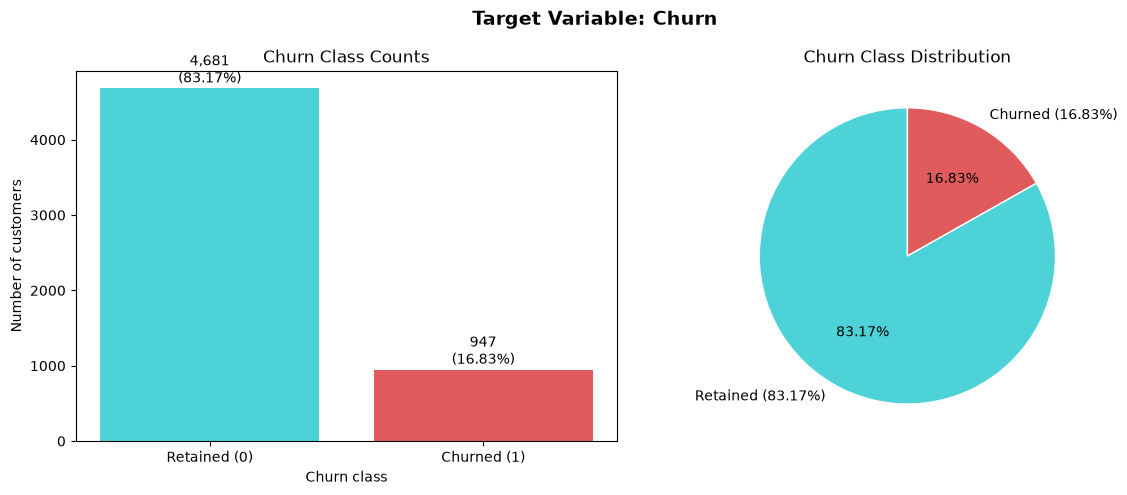

In [107]:
# Check target distribution
churn_counts = df_clean["Churn"].value_counts().sort_index()
churn_percentages = (df_clean["Churn"].value_counts(normalize=True).sort_index() * 100).round(2)

target_distribution = pd.DataFrame({
    "count": churn_counts,
    "percentage": churn_percentages
})

print("Target distribution:")
print(pd.DataFrame({
    "Count": churn_counts,
    "Percentage (%)": churn_percentages
}))

# Visualize target distribution with count bar chart and percentage pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["Retained (0)", "Churned (1)"]
counts = target_distribution["count"].values
percentages = target_distribution["percentage"].values

# Bar chart
palette = ["#4CD2D7", '#E05C5C']
bars = axes[0].bar(labels, counts, color=palette)
axes[0].set_title("Churn Class Counts")
axes[0].set_ylabel("Number of customers")
axes[0].set_xlabel("Churn class")

for bar, count, pct in zip(bars, counts, percentages):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{count:,}\n({pct:.2f}%)",
        ha="center",
        fontsize=10
    )

# Pie chart
palette = ["#4CD2D7", '#E05C5C']
axes[1].pie(
    counts,
    labels=[f"Retained ({percentages[0]:.2f}%)", f"Churned ({percentages[1]:.2f}%)"],
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    colors=palette
)

axes[1].set_title("Churn Class Distribution")

plt.suptitle("Target Variable: Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


The target distribution shows that 947 customers are churners, corresponding to 16.83% of the dataset, while 4,681 customers are retained, corresponding to 83.17%. The dataset is therefore clearly imbalanced toward retained customers, although the minority class remains sufficiently represented for supervised propensity modeling.

This imbalance has direct implications for the modeling phase. A model evaluated only with accuracy could appear effective by mainly predicting the majority class, while still failing to identify many customers who are actually at risk of leaving.

For this reason, the evaluation will not rely only on accuracy. Recall, F1-score and lift will be especially important because the business goal is not simply to classify customers correctly, but to prioritize customers who should receive retention actions. In this context, a false nagative is more costly than a false positive: missing a real churner means that no retention campaign is activated for a customer who may leave, while contacting a retained customer mainly creates a potential marketing cost.

## **Exploratory Data Analysis**

The exploratory analysis focuses on understanding which customer signals are associated with churn before moving to predictive modeling. In this project, the main objective is not only to describe the dataset, but to identify behavioral and satisfaction-related patterns that can later support retention actions.

The first part of the EDA analyzes the relationship between ```Complain```, ```SatisfactionScore``` and ```Churn```. These variables are especially relevant because they capture customer experience: complaints indicate explicit dissatisfaction, while satisfaction scores provide a direct signal of perceived sevice quality.

Churn rate by complain status:
          customer_count  churners  churn_rate
Complain                                      
0                   4026       440      10.930
1                   1602       507      31.650


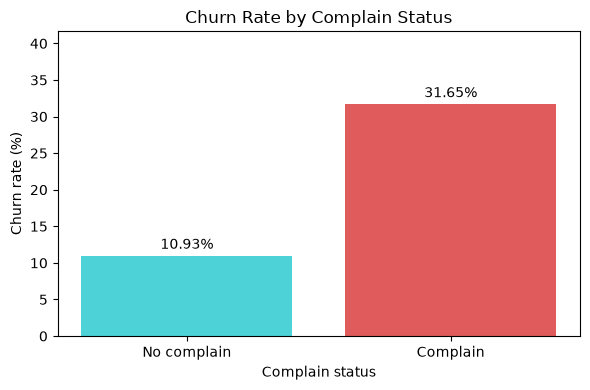

In [108]:
# Analyze churn rate by complain status
complain_churn = (
    df_clean
    .groupby("Complain")["Churn"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customer_count",
        "sum": "churners",
        "mean": "churn_rate"
    })
)

complain_churn["churn_rate"] = (complain_churn["churn_rate"] * 100).round(2)

complain_churn

print("Churn rate by complain status:")
print(complain_churn[["customer_count", "churners", "churn_rate"]])

# Visualize churn rate by complain status
fig, ax = plt.subplots(figsize=(6, 4))

labels = ["No complain", "Complain"]
values = complain_churn["churn_rate"].values

bars = ax.bar(labels, values, color=["#4CD2D7", "#E05C5C"])

ax.set_title("Churn Rate by Complain Status")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("Complain status")
ax.set_ylim(0, max(values) + 10)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

```Complain``` shows one of the clearest customer experience signals in the exploratory analysis. Customers without complaints have a churn rate of 10.93%, while customers with complaints reach 31.65%. This means that the churn rate is almost three times higher among customers who reported a complain.

This result suggests that explicit dissatisfaction is strongly connected to the probability of leaving. A complain is not only a service event, but also a warning signal that the customer relationship may be already damaged. For the future modeling phase, ```Complain``` is therefore expected to be an important predictor because it separates two groups with very different churn risk levels.

Churn rate by satisfaction score:
                   customer_count  churners  churn_rate
SatisfactionScore                                      
1                            1163       134      11.520
2                             586        74      12.630
3                            1698       292      17.200
4                            1073       183      17.050
5                            1108       264      23.830


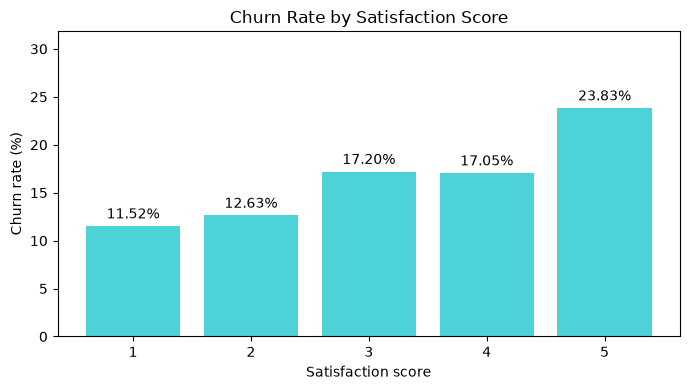

In [109]:
# Analyze churn rate by satisfaction score
satisfaction_churn = (
    df_clean
    .groupby("SatisfactionScore")["Churn"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customer_count",
        "sum": "churners",
        "mean": "churn_rate"
    })
)

satisfaction_churn["churn_rate"] = (satisfaction_churn["churn_rate"] * 100).round(2)

satisfaction_churn

print("Churn rate by satisfaction score:")
print(satisfaction_churn[["customer_count", "churners", "churn_rate"]])

# Visualize churn rate by satisfaction score
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    satisfaction_churn.index.astype(str),
    satisfaction_churn["churn_rate"],
    color="#4CD2D7"
)

ax.set_title("Churn Rate by Satisfaction Score")
ax.set_xlabel("Satisfaction score")
ax.set_ylabel("Churn rate (%)")
ax.set_ylim(0, satisfaction_churn["churn_rate"].max() + 8)

for bar, value in zip(bars, satisfaction_churn["churn_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

```SatisfactionScore``` shows a less intuitive pattern than ```Complaint```. The churn rate is relatively low for scores 1 and 2, equal to 11.51% and 12.63%, then increases for scores 3 and 4 around 17% and reaches the highest value for score 5, with a churn rate of 23.83%.

This means that satisfaction alone does not explain churn in a linear way. In this dataset, highly satisfied customers can still churn, which suggests that leaving the platform may also depend on other factors such as low engagement, weak purchase frequency, long inactivity, delivery distance, coupon sensitivity or changes in customer needs.

For the modeling phase, ```SatisfactionScore``` should still be included because it capstures customer experience, but it should not be interpreted in isolation. From a retention strategy perspective, this result is important because it shows that high satisfaction does not automatically guarantee loyalty: the company should combine satisfaction signals with behavioral and transactional indicators to identify customers who appear satisfied but are still at risk of leaving. 

From a marketing perspective, the variable is also actionable. Customers with complaints should be treated as a priority group for retention actions, because the company can intervene with service recovery, personalized support or targeted reassurance before the relationship deteriorates further.

After analyzing Complain and SatisfactionScore separately, the correlation matrix provides a compact view of how these customer experience variables are associated with Churn. This helps distinguish between visually observed churn patterns and their linear relationship with the target.

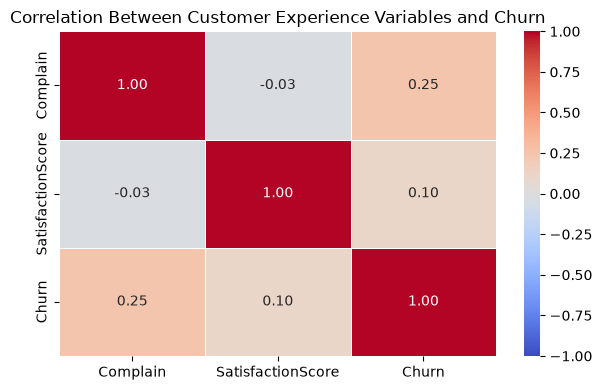

,Complain,SatisfactionScore,Churn
Complain,1.000,-0.030,0.250
SatisfactionScore,-0.030,1.000,0.104
Churn,0.250,0.104,1.000


In [110]:
# Correlation between customer experience variables and churn
experience_corr_vars = ["Complain", "SatisfactionScore", "Churn"]

experience_corr = df_clean[experience_corr_vars].corr(
    method="spearman"
)
plt.figure(figsize=(6, 4))

sns.heatmap(
    experience_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Between Customer Experience Variables and Churn")
plt.tight_layout()
plt.show()

experience_corr

The correlation matrix adds a more compact view of the customer experience signals. Complain has a stronger positive correlation with Churn than SatisfactionScore, confirming that explicit dissatisfaction is more directly associated with churn risk than the satisfaction score alone.

At the same time, both correlations are moderate rather than extremely high. This is important for the modeling phase because churn is not driven only by customer experience variables: behavioral, transactional and relationship maturity signals are also needed to estimate churn propensity reliably.

Finally, the correlation between Complain and SatisfactionScore is close to zero, meaning that the two variables are not redundant. They should both be retained because they capture different dimensions of customer experience.

### **Customer Experience Risk Matrix**

The previous analysis showed that Complain and SatisfactionScore capture different aspects of customer experience. To make this insight more actionable for retention strategy, the two variables are combined into a customer experience risk matrix. This allows us to compare churn across customers with and without compalints, while also distinguishing between lower and higher satisfaction levels.

In [111]:
# Create a customer experience risk matrix based on Complain and SatisfactionScore

df_clean["SatisfactionGroup"] = np.where(
    df_clean["SatisfactionScore"] >= 4,
    "High satisfaction",
    "Low/medium satisfaction"
)

df_clean["ComplaintStatus"] = np.where(
    df_clean["Complain"] == 1,
    "Complaint",
    "No complaint"
)

experience_matrix = (
    df_clean
    .groupby(["ComplaintStatus", "SatisfactionGroup"], observed=False)["Churn"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customer_count",
        "sum": "churners",
        "mean": "churn_rate"
    })
)

experience_matrix["churn_rate"] = (experience_matrix["churn_rate"] * 100).round(2)

experience_matrix

customer_count  churners  churn_rate
ComplaintStatus SatisfactionGroup                                            
Complaint       High satisfaction                   589       223      37.860
                Low/medium satisfaction            1013       284      28.040
No complaint    High satisfaction                  1592       224      14.070
                Low/medium satisfaction            2434       216       8.870

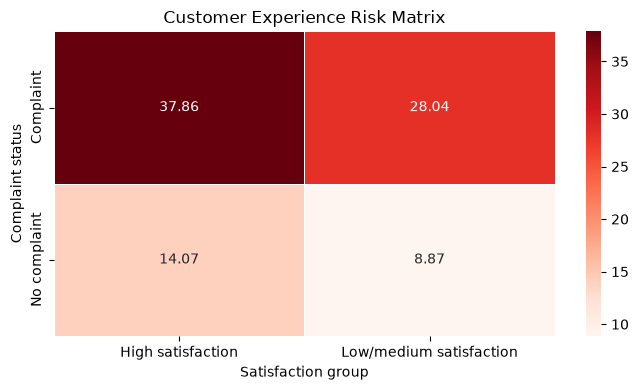

In [112]:
# Visualize churn rate by complaint status and satisfaction group

experience_pivot = experience_matrix["churn_rate"].unstack()

plt.figure(figsize=(7, 4))

sns.heatmap(
    experience_pivot,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Customer Experience Risk Matrix")
plt.xlabel("Satisfaction group")
plt.ylabel("Complaint status")
plt.tight_layout()
plt.show()

The Customer Experience Risk Matrix reveals a counterintuitive pattern: the highest churn rate, equal to 37.86%, is found among customers who reported a complaints but also have a high satisfaction. This pattern is consistent with customers who may still value the platform overall but have experienced a specific unresolved negative episode. The result should be interpreted as an actionable association rather than evidence of a causal effect. In this sense, the risk may be linked less to general dissatisfaction and more to unresolved service friction or insufficient service recovery.  

In contrast, customers with low/medium satisfaction but no complaint show a much lower churn rate, equal to 8.87%. This indicates that dissatisfaction alone does not necessarily translate into churn unless it becomes explicit or is connected to a concrete negative event.

The matrix is more informative than analyzing Complain and SatisfactionScore separately, because it shows that complaint status changes the meaning of satisfaction. From a retention perspective, customers with complaints should be treated as a priority segment, especially when they still report high satisfaction, because they may be recoverable if the company intervenes quickly with targeted support, reassurance or service recovery actions.

### **Multi Device Friction Check**

The previous analysis showed that complaints are a strong customer-experience risk signal. The next step examines whether this relationship changes according to the number of devices registered to the customer account.

NumberOfDeviceRegistered measures the number of devices associated with the customer, not how frequently those devices are actively used. The variable is therefore grouped by registered-device count and combined with complaint status to examine whether account complexity and service friction are jointly associated with churn.

In [113]:
# Create registered-device count groups
df_clean["DeviceCountGroup"] = pd.cut(
    df_clean["NumberOfDeviceRegistered"],
    bins=[0, 2, 4, 6],
    labels=[
        "1–2 registered devices",
        "3–4 registered devices",
        "5–6 registered devices"
    ],
    include_lowest=True
)

# Analyze churn rate by registered-device count and complaint status
device_complaint_churn = (
    df_clean
    .groupby(
        ["DeviceCountGroup", "ComplaintStatus"],
        observed=False
    )["Churn"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customer_count",
        "sum": "churners",
        "mean": "churn_rate"
    })
)

device_complaint_churn["churn_rate"] = (
    device_complaint_churn["churn_rate"] * 100
).round(2)

device_complaint_churn

customer_count  churners  churn_rate
DeviceCountGroup       ComplaintStatus                                      
1–2 registered devices Complaint                   144        26      18.060
                       No complaint                367        22       5.990
3–4 registered devices Complaint                  1159       353      30.460
                       No complaint               2916       292      10.010
5–6 registered devices Complaint                   299       128      42.810
                       No complaint                743       126      16.960

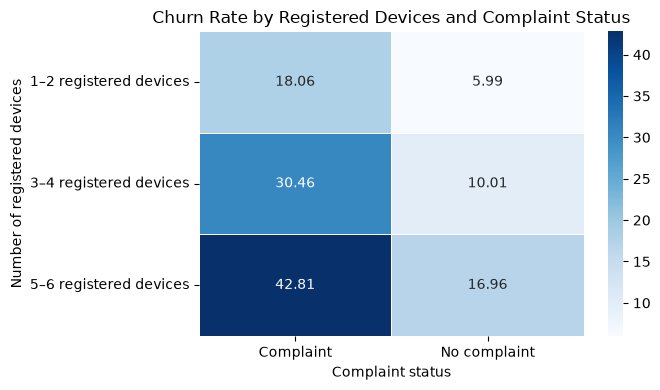

In [114]:
# Visualize churn rate by registered-device count and complaint status
device_complaint_pivot = (
    device_complaint_churn["churn_rate"]
    .unstack()
)

plt.figure(figsize=(7, 4))

sns.heatmap(
    device_complaint_pivot,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Churn Rate by Registered Devices and Complaint Status")
plt.xlabel("Complaint status")
plt.ylabel("Number of registered devices")
plt.tight_layout()
plt.show()

The registered-device analysis reveals a consistent descriptive pattern. Among customers without complaints, the churn rate increases from 5.99% for customers with 1–2 registered devices to 16.96% for customers with 5–6 registered devices. Among customers who submitted a complaint, the churn rate increases from 18.06% to 42.81% across the same device-count groups.

The highest observed churn rate therefore occurs among customers who have both a complaint and 5–6 registered devices. This may indicate that service friction becomes more relevant when the customer journey involves several registered access points. However, the dataset does not indicate whether all registered devices are actively used, so registered-device count should not be interpreted as a direct measure of platform engagement.

From a retention perspective, customers combining a complaint with a high registered-device count may require coordinated service recovery across channels, clearer account support and reassurance that the reported issue has been resolved.

### **Categorical churn patterns**

After analyzing the main customer experience variables, the next step is to examine whether churn risk changes across broader customer segments. These categorical variables describe how customers access the platform, how they pay, what they usually buy and their basic profile characteristics.

This analysis is useful because churn propensity may depend not only on dissatisfaction or satisfaction scores, but also on different commercial habits, payment preferences and relationship contexts.

In [115]:
# Check updated category distribution
df_clean["PreferredOrderCat"].value_counts(dropna=False)

PreferredOrderCat
Mobile Phone          2079
Laptop & Accessory    2049
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64

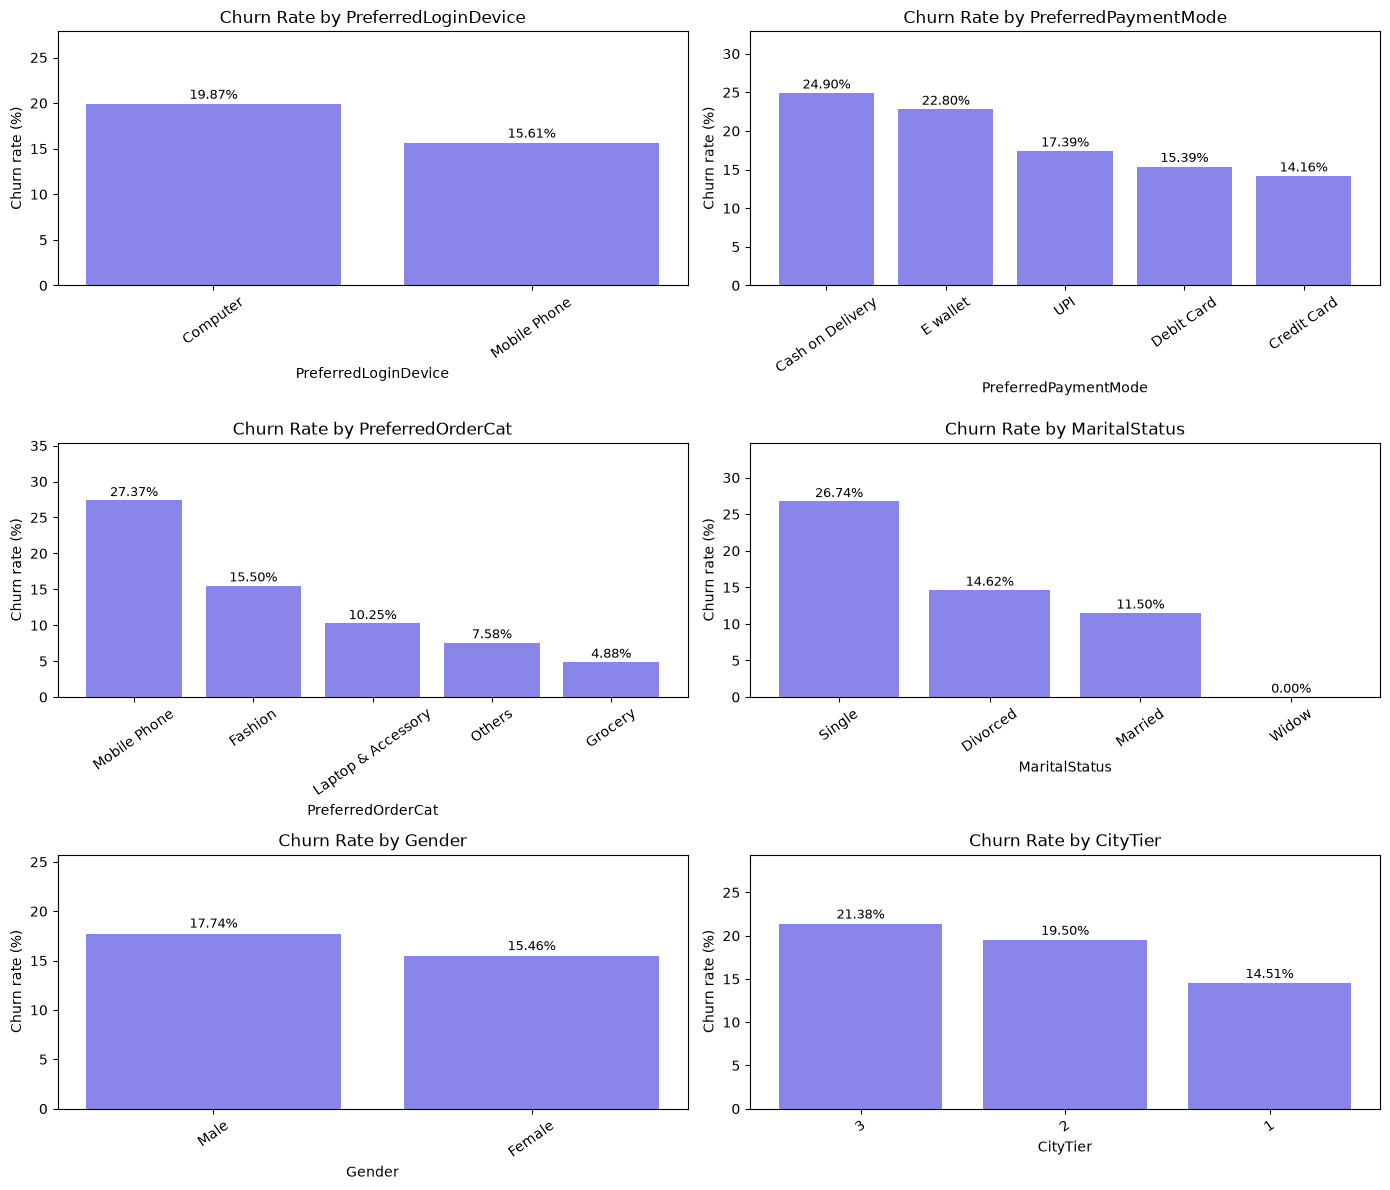

In [116]:
# Analyze churn rate across selected categorical variables
categorical_target_cols = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "PreferredOrderCat",
    "MaritalStatus",
    "Gender",
    "CityTier"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_target_cols):
    churn_by_category = (
        df_clean
        .groupby(col)["Churn"]
        .mean()
        .sort_values(ascending=False) * 100
    ).round(2)

    bars = axes[i].bar(
        churn_by_category.index.astype(str),
        churn_by_category.values,
        color="#8A85E9"
    )

    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Churn rate (%)")
    axes[i].set_ylim(0, churn_by_category.max() + 8)
    axes[i].tick_params(axis="x", rotation=35)

    for bar, value in zip(bars, churn_by_category.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.6,
            f"{value:.2f}%",
            ha="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

The categorical analysis shows that churn risk changes across several customer segments. PreferredOrderCat is one of the clearest signals: after merging Mobile and MobilePhone, the mobile category has the highest churn rate, equal to 27.37%, while Grocery has the lowest churn rate, equal to 4.88%. This suggests that product preference captures different levels of purchase recurrence and customer attachment.

PreferredPaymentMode also shows relevant differences. Customers using COD have the highest churn rate, 24.90%, followed by E wallet at 22.80%, while credit card users show the lowest churn rate, 14.16%. Payment behavior may therefore reflect different levels of trust, habit or transactional stability.

Customer profile and access variables add further segmentation signals: computer users, single customers and CityTier 3 customers show higher churn rates, while gender differences are smaller. Overall, these variables should be encoded and included in the model because they contain category-specific churn patterns that can also suport targeted retention actions.

### **Numerical churn patterns**

The numerical analysis compares retained and churned customers across relationship, engagement, transactional and monetary variables. This step helps identify whether churners differ from retained customers in terms of tenure, purchase recency, app usage, coupon behavior, device usage and cashback exposure.

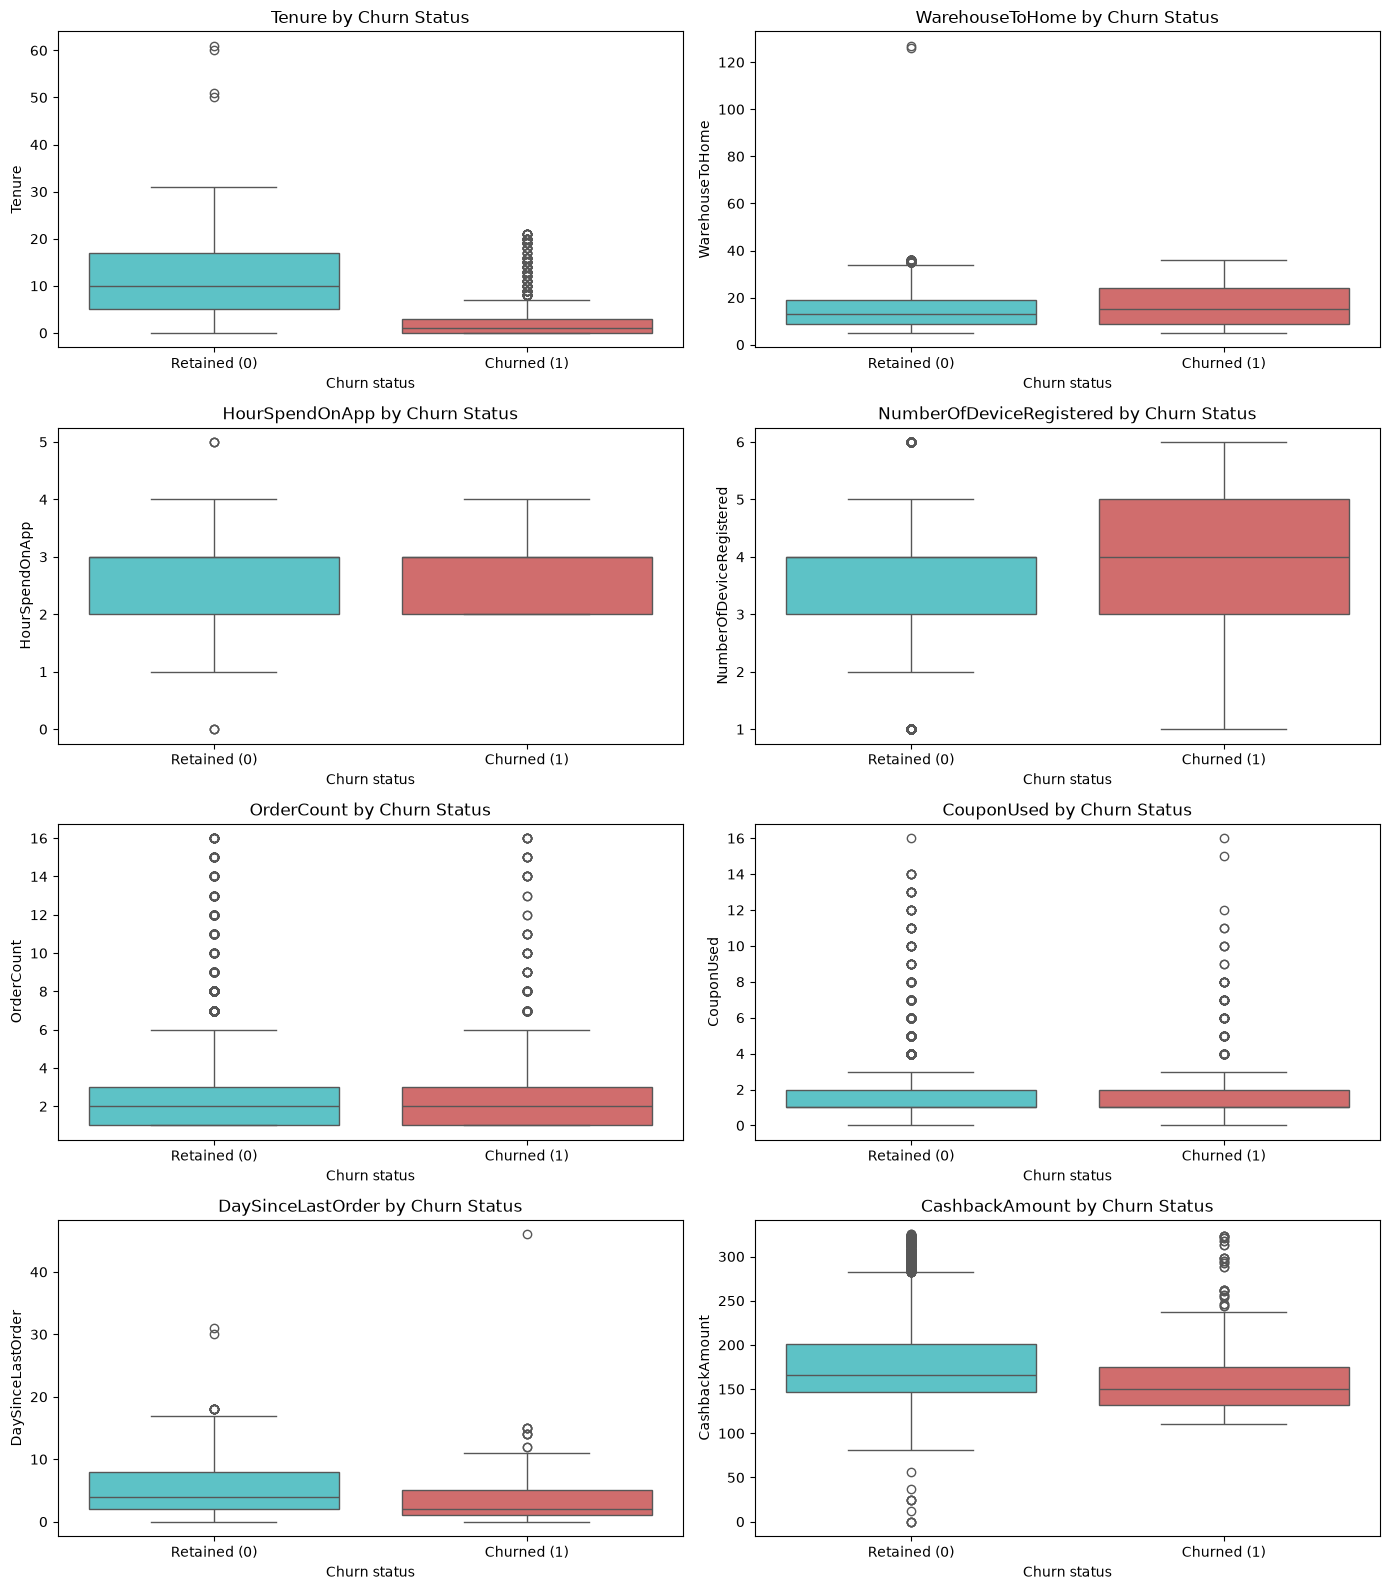

In [117]:
# Compare numerical variables by churn status
numerical_target_cols = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "OrderCount",
    "CouponUsed",
    "DaySinceLastOrder",
    "CashbackAmount"
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.ravel()

for i, col in enumerate(numerical_target_cols):
    sns.boxplot(
        data=df_clean,
        x="Churn",
        y=col,
        ax=axes[i],
        palette=["#4CD2D7", "#E05C5C"]
    )
    
    axes[i].set_title(f"{col} by Churn Status")
    axes[i].set_xlabel("Churn status")
    axes[i].set_ylabel(col)
    axes[i].set_xticklabels(["Retained (0)", "Churned (1)"])

plt.tight_layout()
plt.show()

The numerical comparison shows that churn is mainly linked to relationship maturity and customer value signals. Tenure is the clearest difference: churned customers have much lower tenure than retained customers, suggesting that newer customers are more fragile and less attached to the platform.

NumberOfDeviceRegistered is higher among churners, which may indicate fragmented or less stable engagement rather than stronger loyalty. CashbackAmount tends to be lower for churners, suggesting weaker reward exposure or lower perceived economic value.

Other variables, such as OrderCount, CouponUsed and HourSpendOnApp, show more overlap between retained and churned customers. This suggests that churn should be modeled as a combination of customer experience, relationship maturity, transactional behavior and commerical preference signals, rather than as the effect of a single variable.

## **Churn probability by tenure and purchase recency groups**

Tenure and DaySinceLastOrder are transformed into business-oriented groups to make the observed churn patterns easier to interpret and translate into retention actions. The thresholds are defined independently of the target variable and are not selected to maximize differences in churn.

For Tenure, the cut-offs at 6 and 18 months distinguish newer customers from customers with a developing or more established relationship. For DaySinceLastOrder, the cut-offs at 3 and 10 days distinguish recent, intermediate and longer purchase recency without assuming that customers with a longer interval are necessarily inactive.

Infinite outer bounds are used so that the grouping rules remain valid for future customers whose values may exceed the range observed in the current dataset. The observed churn rates are therefore used to describe the predefined groups rather than to determine their boundaries.

Churn rate by tenure group:
                         customer_count  churners  churn_rate
TenureGroup                                                  
New customers                      2148       696      32.400
Medium-tenure customers            2214       132       5.960
Long-tenure customers              1002        38       3.790

Churn rate by days since last order group:
                         customer_count  churners  churn_rate
DaysSinceLastOrderGroup                                      
Recent order                       2802       604      21.560
Intermediate recency               2211       270      12.210
Longer recency                      308        19       6.170


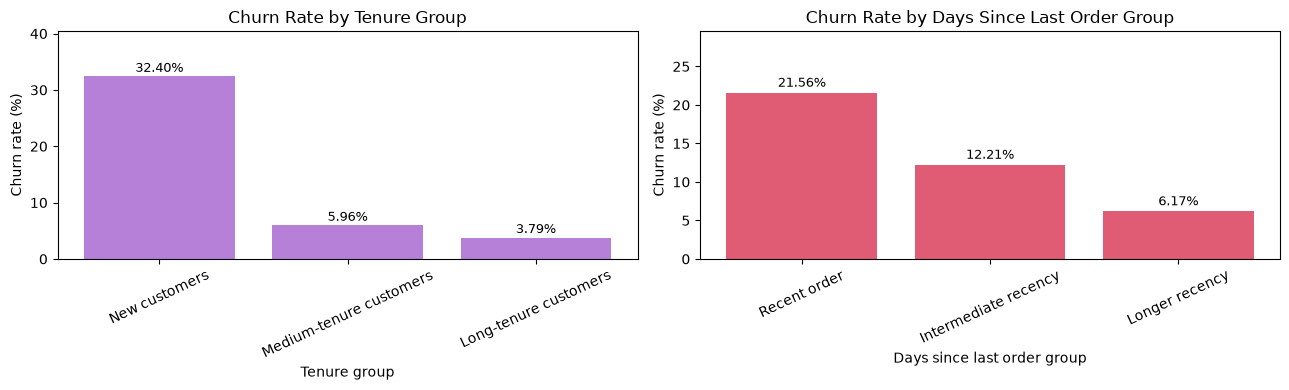

In [118]:
# Create business-oriented groups for Tenure and DaySinceLastOrder
df_clean["TenureGroup"] = pd.cut(
    df_clean["Tenure"],
    bins=[-np.inf, 6, 18, np.inf],
    labels=[
        "New customers",
        "Medium-tenure customers",
        "Long-tenure customers"
    ]
)

df_clean["DaysSinceLastOrderGroup"] = pd.cut(
    df_clean["DaySinceLastOrder"],
    bins=[-np.inf, 3, 10, np.inf],
    labels=[
        "Recent order",
        "Intermediate recency",
        "Longer recency"
    ]
)

# Calculate churn rate by Tenure group
tenure_churn = (
    df_clean
    .groupby("TenureGroup", observed=False)["Churn"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customer_count",
        "sum": "churners",
        "mean": "churn_rate"
    })
)

tenure_churn["churn_rate"] = (tenure_churn["churn_rate"] * 100).round(2)

# Calculate churn rate by DaysSinceLastOrder group
recency_churn = (
    df_clean
    .groupby("DaysSinceLastOrderGroup", observed=False)["Churn"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customer_count",
        "sum": "churners",
        "mean": "churn_rate"
    })
)

recency_churn["churn_rate"] = (recency_churn["churn_rate"] * 100).round(2)

print("Churn rate by tenure group:")
print(tenure_churn)

print("\nChurn rate by days since last order group:")
print(recency_churn)

# Visualize churn rate by Tenure and DaysSinceLastOrder groups
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tenure plot
bars_1 = axes[0].bar(
    tenure_churn.index.astype(str),
    tenure_churn["churn_rate"],
    color="#B680D9"
)

axes[0].set_title("Churn Rate by Tenure Group")
axes[0].set_xlabel("Tenure group")
axes[0].set_ylabel("Churn rate (%)")
axes[0].set_ylim(0, tenure_churn["churn_rate"].max() + 8)
axes[0].tick_params(axis="x", rotation=25)

for bar, value in zip(bars_1, tenure_churn["churn_rate"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

# DaysSinceLastOrder plot
bars_2 = axes[1].bar(
    recency_churn.index.astype(str),
    recency_churn["churn_rate"],
    color="#E05C74"
)

axes[1].set_title("Churn Rate by Days Since Last Order Group")
axes[1].set_xlabel("Days since last order group")
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_ylim(0, recency_churn["churn_rate"].max() + 8)
axes[1].tick_params(axis="x", rotation=25)

for bar, value in zip(bars_2, recency_churn["churn_rate"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

The grouped analysis shows that Tenure is one of the strongest churn signals in the dataset. New customers have a churn rate of 32.40%, while the rate falls to 5.96% among medium-tenure customers and 3.79% among long-tenure customers. This suggests that churn risk is concentrated in the early relationship stage, before customers have developed stable purchasing habits, trust or switching costs with the platform.

The pattern for DaySinceLastOrder is less intuitive. Customers in the recent-order group show the highest churn rate, equal to 21.56%, while customers with intermediate and longer recency show lower rates of 12.21% and 6.17%. Purchase recency should therefore not be interpreted as a direct measure of disengagement in this dataset. A customer may leave shortly after a transaction because of dissatisfaction, delivery friction, product experience or a weakly established relationship.

From a propensity-modeling perspective, these results confirm that churn should not be interpreted from one variable alone. Tenure provides a clear relationship-maturity signal, while DaySinceLastOrder needs to be combined with complaints, satisfaction, payment behaviour and product category.


The previous grouped analysis provides an interpretable segmentation of customers into broad relationship-maturity and purchase-recency groups. To examine these patterns at a more granular level, Tenure and DaySinceLastOrder are now divided into quantile-based intervals containing approximately similar numbers of customers.

For each interval, the observed churn rate is calculated directly. This provides a clearer representation of how the empirical probability of churn changes across the range of the two numerical variables.

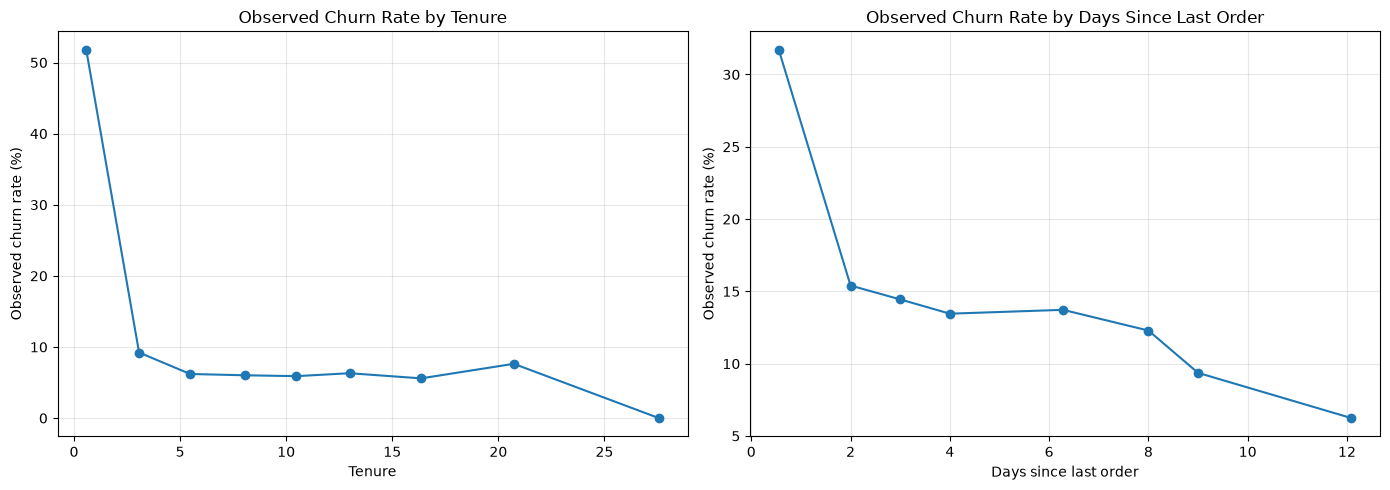

In [119]:
# Visualize the observed churn rate across Tenure and DaySinceLastOrder
probability_variables = ["Tenure", "DaySinceLastOrder"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, variable in zip(axes, probability_variables):

    # Retain complete observations for the variable under analysis
    temp = df_clean[[variable, "Churn"]].dropna().copy()

    # Create quantile-based intervals with approximately similar group sizes
    temp["value_bin"] = pd.qcut(
        temp[variable],
        q=10,
        duplicates="drop"
    )

    # Calculate the observed churn rate within each interval
    churn_profile = (
        temp
        .groupby("value_bin", observed=True)
        .agg(
            average_value=(variable, "mean"),
            churn_rate=("Churn", "mean"),
            customer_count=("Churn", "size")
        )
        .reset_index()
    )

    churn_profile["churn_rate"] *= 100

    ax.plot(
        churn_profile["average_value"],
        churn_profile["churn_rate"],
        marker="o"
    )
    
    ax.set_title(
    "Observed Churn Rate by Days Since Last Order"
    if variable == "DaySinceLastOrder"
    else "Observed Churn Rate by Tenure"
    )
    
    ax.set_xlabel(
    "Days since last order"
    if variable == "DaySinceLastOrder"
    else "Tenure"
    )
    
    ax.set_ylabel("Observed churn rate (%)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The quantile-based analysis confirms that customer relationship maturity is strongly associated with churn. The observed churn rate exceeds 50% among customers with the shortest tenure, then falls sharply once the relationship extends beyond the earliest stage. After this initial decline, churn remains comparatively low across the more established tenure intervals. This pattern indicates that the first months of the customer relationship represent the most vulnerable retention period.

The pattern for DaySinceLastOrder is less intuitive. Customers with the most recent purchases show the highest observed churn rate, while the rate generally decreases as the number of days since the last order increases. Therefore, purchase inactivity alone should not be interpreted as a direct churn signal in this dataset. A recent transaction may still be followed by churn because of dissatisfaction, delivery friction, product experience or an insufficiently established relationship.

These results are descriptive rather than causal. In particular, the apparent effect of purchase recency may be influenced by customer tenure and other characteristics. For this reason, DaysSinceLastOrder is analyzed jointly with TenureGroup in the following section.

In [120]:
# Check churn rate by both TenureGroup and DaysSinceLastOrderGroup
tenure_recency_churn = (
    df_clean
    .groupby(["TenureGroup", "DaysSinceLastOrderGroup"], observed=False)["Churn"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customer_count",
        "sum": "churners",
        "mean": "churn_rate"
    })
)

tenure_recency_churn["churn_rate"] = (tenure_recency_churn["churn_rate"] * 100).round(2)

tenure_recency_churn

customer_count  churners  \
TenureGroup             DaysSinceLastOrderGroup                             
New customers           Recent order                       1233       466   
                        Intermediate recency                792       185   
                        Longer recency                       27        13   
Medium-tenure customers Recent order                        955        53   
                        Intermediate recency                931        55   
                        Longer recency                      191         6   
Long-tenure customers   Recent order                        400        14   
                        Intermediate recency                440        20   
                        Longer recency                       88         0   

                                                 churn_rate  
TenureGroup             DaysSinceLastOrderGroup              
New customers           Recent order                 37.790  
                        Intermediate recency         23.360  
                        Longer recency               48.150  
Medium-tenure customers Recent order                  5.550  
                        Intermediate recency          5.910  
                        Longer recency                3.140  
Long-tenure customers   Recent order                  3.500  
                        Intermediate recency          4.550  
                        Longer recency                0.000

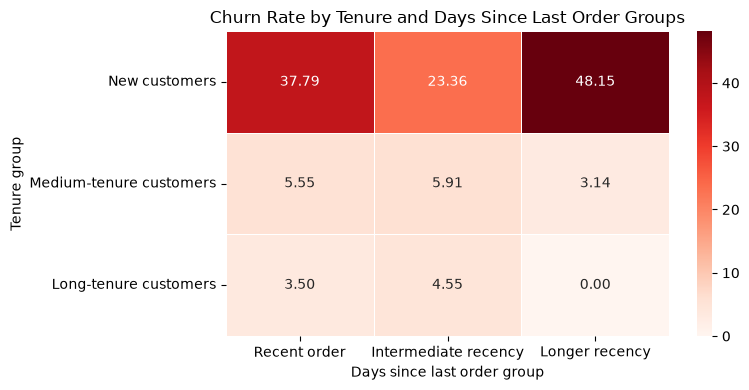

In [121]:
# Pivot table for visualization
tenure_recency_pivot = tenure_recency_churn["churn_rate"].unstack()

plt.figure(figsize=(8, 4))
sns.heatmap(
    tenure_recency_pivot,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Churn Rate by Tenure and Days Since Last Order Groups")
plt.xlabel("Days since last order group")
plt.ylabel("Tenure group")
plt.tight_layout()
plt.show()

The interaction indicates that the relationship between purchase recency and churn varies substantially across tenure groups. The apparently counterintuitive aggregate pattern is therefore partly associated with differences in customer maturity. Among new customers, churn remains elevated across all recency groups and reaches 48.15% in the longer-recency group. In contrast, medium-tenure and long-tenure customers show comparatively low churn rates across the different recency categories.

These results suggest that DaySinceLastOrder becomes more informative when considered jointly with Tenure. Longer purchase recency is not associated with the same level of risk for every customer: its relationship with churn appears stronger when the customer relationship is still recent and not yet consolidated.

From an operational perspective, this pattern supports an early-retention strategy focused on new customers who also show weaker purchase-recency signals. However, the new-customer and longer-recency group contains only 27 customers. Its churn rate of 48.15% should therefore be interpreted as a warning signal rather than as a stable estimat

In [122]:
# Correlation of numerical variables with Churn
numeric_corr_cols = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "Complain",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

churn_corr = (
    df_clean[numeric_corr_cols + ["Churn"]]
    .corr(method="spearman")["Churn"]
    .drop("Churn")
    .sort_values()
)
churn_corr_table = churn_corr.to_frame(
    name="spearman_correlation_with_churn"
)

churn_corr_table


,spearman_correlation_with_churn
Tenure,-0.404
DaySinceLastOrder,-0.187
CashbackAmount,-0.172
OrderCount,-0.029
OrderAmountHikeFromlastYear,-0.020
CouponUsed,-0.015
HourSpendOnApp,0.016
NumberOfAddress,0.029
WarehouseToHome,0.081
NumberOfDeviceRegistered,0.101


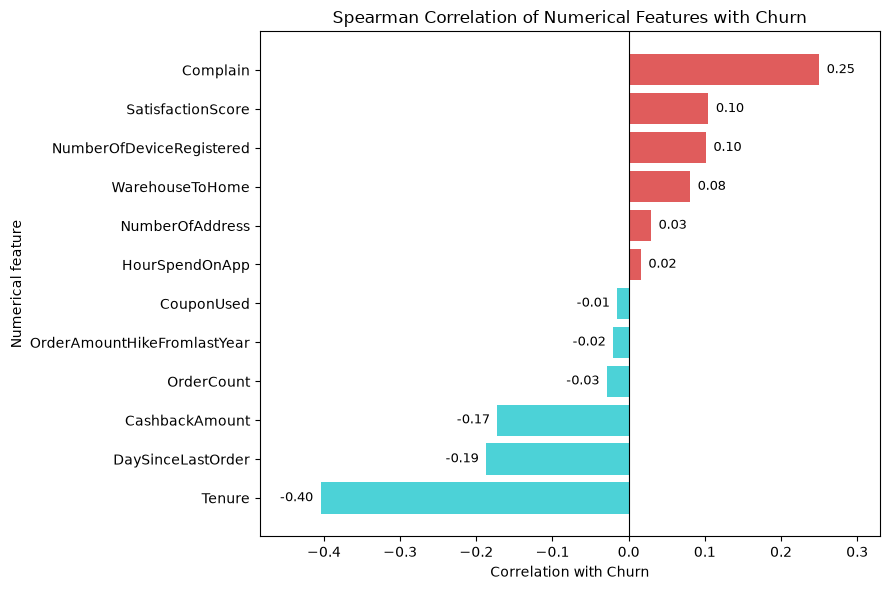

In [123]:
# Visualize numerical correlations with Churn
plt.figure(figsize=(9, 6))
colors = ["#E05C5C" if value > 0 else "#4CD2D7" for value in churn_corr.values]

bars = plt.barh(
    churn_corr.index,
    churn_corr.values,
    color=colors
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title("Spearman Correlation of Numerical Features with Churn")
plt.xlabel("Correlation with Churn")
plt.ylabel("Numerical feature")

# Add more space on both sides so labels do not overlap
plt.xlim(churn_corr.min() - 0.08, churn_corr.max() + 0.08)

for bar, value in zip(bars, churn_corr.values):
    if value >= 0:
        x_position = value + 0.01
        alignment = "left"
    else:
        x_position = value - 0.01
        alignment = "right"
    
    plt.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha=alignment,
        fontsize=9
    )

plt.tight_layout()
plt.show()

The correlation ranking provides a compact quantitative summary of the numerical signals associated with Churn.  
Tenure shows the strongest negative correlation, confirming that relationship maturity is protective, while Complain is the strongest positive signal, confirming the importance of explicit dissatisfaction.

Other correlations are weaker, which suggests that churn cannot be explained by a single numerical variable. These results support the previous EDA: the predictive model should combine experience, relationship maturity, engagement and transactional variables rather than relying on one isolated driver.

## **Feature Engineering**

Feature engineering transforms the available customer attributes into deterministic and interpretable model-ready variables. The goal is to represent relationship maturity, purchase recency, customer experience risk, registered-device complexity and commercial behaviour in a more interpretable form.

The thresholds used for Tenure and DaySinceLastOrder are fixed business-oriented rules defined independently of the Churn target. They are not estimated from the observed churn rates or optimized to maximize target separation. Similarly, the interaction segments are predefined combinations of existing customer attributes and do not rely on the target variable.

Missing values in grouped features are kept as explicit “Unknown” categories, so that no customers are removed and missingness is preserved as a possible signal instead of being hidden before the modeling pipeline.

Missingness is concentrated in a limited set of behavioural variables. Preserving an explicit unknown category for the engineered groups allows the model to retain this information without assuming that missing values are equivalent to the most frequent behavioural profile.

In [124]:
# Create a modeling copy from the cleaned dataset
df_model = df_clean.copy()

# Relationship maturity feature based on business-oriented Tenure thresholds
df_model["TenureGroup"] = pd.cut(
    df_model["Tenure"],
    bins=[-np.inf, 6, 18, np.inf],
    labels=[
        "New customers",
        "Medium-tenure customers",
        "Long-tenure customers"
    ]
)

# Purchase recency feature based on business-oriented thresholds
df_model["DaysSinceLastOrderGroup"] = pd.cut(
    df_model["DaySinceLastOrder"],
    bins=[-np.inf, 3, 10, np.inf],
    labels=[
        "Recent order",
        "Intermediate recency",
        "Longer recency"
    ]
)

# Explicit categories for customers with missing Tenure or DaySinceLastOrder
df_model["TenureGroup"] = (
    df_model["TenureGroup"]
    .astype("object")
    .fillna("Unknown tenure")
)

df_model["DaysSinceLastOrderGroup"] = (
    df_model["DaysSinceLastOrderGroup"]
    .astype("object")
    .fillna("Unknown recency")
)

# Satisfaction grouping used in the Customer Experience Risk Matrix
df_model["SatisfactionGroup"] = np.where(
    df_model["SatisfactionScore"] >= 4,
    "High satisfaction",
    "Low/medium satisfaction"
)

# Complaint status as interpretable categorical label
df_model["ComplaintStatus"] = np.where(
    df_model["Complain"] == 1,
    "Complaint",
    "No complaint"
)

# Customer Experience Risk Segment
df_model["ExperienceRiskSegment"] = (
    df_model["ComplaintStatus"] + " | " + df_model["SatisfactionGroup"]
)

# Registered-device count group based on NumberOfDeviceRegistered
df_model["DeviceCountGroup"] = pd.cut(
    df_model["NumberOfDeviceRegistered"],
    bins=[0, 2, 4, 6],
    labels=[
        "1–2 registered devices",
        "3–4 registered devices",
        "5–6 registered devices"
    ],
    include_lowest=True
)

# Convert DeviceCountGroup to text before combining it with ComplaintStatus
df_model["DeviceCountGroup"] = (
    df_model["DeviceCountGroup"]
    .astype("object")
    .fillna("Unknown registered-device count")
)

# Registered-device count and complaint interaction segment
df_model["DeviceComplaintSegment"] = (
    df_model["DeviceCountGroup"].astype(str)
    + " | "
    + df_model["ComplaintStatus"]
)

# Coupon usage rate: promotional dependence relative to order volume
df_model["CouponUsageRate"] = (
    df_model["CouponUsed"] / df_model["OrderCount"].replace(0, np.nan)
)

# Cashback per order: reward intensity relative to order volume
df_model["CashbackPerOrder"] = (
    df_model["CashbackAmount"] / df_model["OrderCount"].replace(0, np.nan)
)

# Sanity checks on engineered features
print("Missing values in engineered categorical features:")
print(df_model[
    [
        "TenureGroup",
        "DaysSinceLastOrderGroup",
        "SatisfactionGroup",
        "ComplaintStatus",
        "ExperienceRiskSegment",
        "DeviceCountGroup",
        "DeviceComplaintSegment"
    ]
].isnull().sum())

print("\nExperience risk segment distribution:")
print(df_model["ExperienceRiskSegment"].value_counts(dropna=False))

print("\nDevice complaint segment distribution:")
print(df_model["DeviceComplaintSegment"].value_counts(dropna=False))

df_model[
    [
        "Tenure", "TenureGroup",
        "DaySinceLastOrder", "DaysSinceLastOrderGroup",
        "Complain", "SatisfactionScore", "ExperienceRiskSegment",
        "NumberOfDeviceRegistered", "DeviceCountGroup", "DeviceComplaintSegment",
        "CouponUsageRate", "CashbackPerOrder"
    ]
].head()

Missing values in engineered categorical features:
TenureGroup                0
DaysSinceLastOrderGroup    0
SatisfactionGroup          0
ComplaintStatus            0
ExperienceRiskSegment      0
DeviceCountGroup           0
DeviceComplaintSegment     0
dtype: int64

Experience risk segment distribution:
ExperienceRiskSegment
No complaint | Low/medium satisfaction    2434
No complaint | High satisfaction          1592
Complaint | Low/medium satisfaction       1013
Complaint | High satisfaction              589
Name: count, dtype: int64

Device complaint segment distribution:
DeviceComplaintSegment
3–4 registered devices | No complaint    2916
3–4 registered devices | Complaint       1159
5–6 registered devices | No complaint     743
1–2 registered devices | No complaint     367
5–6 registered devices | Complaint        299
1–2 registered devices | Complaint        144
Name: count, dtype: int64


,Tenure,TenureGroup,DaySinceLastOrder,DaysSinceLastOrderGroup,Complain,SatisfactionScore,ExperienceRiskSegment,NumberOfDeviceRegistered,DeviceCountGroup,DeviceComplaintSegment,CouponUsageRate,CashbackPerOrder
0,4.000,New customers,5.000,Intermediate recency,1,2,Complaint | Low/medium satisfaction,3,3–4 registered devices,3–4 registered devices | Complaint,1.000,159.930
1,NaN,Unknown tenure,0.000,Recent order,1,3,Complaint | Low/medium satisfaction,4,3–4 registered devices,3–4 registered devices | Complaint,0.000,120.900
2,NaN,Unknown tenure,3.000,Recent order,1,3,Complaint | Low/medium satisfaction,4,3–4 registered devices,3–4 registered devices | Complaint,0.000,120.280
3,0.000,New customers,3.000,Recent order,0,5,No complaint | High satisfaction,4,3–4 registered devices,3–4 registered devices | No complaint,0.000,134.070
4,0.000,New customers,3.000,Recent order,0,5,No complaint | High satisfaction,3,3–4 registered devices,3–4 registered devices | No complaint,1.000,129.600


The resulting dataset contains both the original customer attributes and a set of deterministic, domain-oriented engineered features. The grouped variables use fixed business-oriented cut-offs to make relationship maturity and purchase recency easier to interpret from a marketing perspective, while the interaction variables combine existing customer characteristics into operational customer-level segments.

In particular, ExperienceRiskSegment combines complaint behaviour and satisfaction level, while DeviceComplaintSegment combines registered-device count and complaint status. The ratio features CouponUsageRate and CashbackPerOrder provide normalized commercial signals, making it possible to compare promotional dependence and reward exposure across customers with different order volumes.

None of these feature definitions uses Churn or optimizes categories against the target variable. The same fixed construction rules can therefore be applied consistently to both training and test observations. The next step is to separate the target from the predictors and prepare the data for the train-test split and preprocessing pipeline.

## **Target and Feature Separation**

After completing feature engineering, the dataset is divided into predictors and target variable. The target is Churn, which represents whether a customer left the platform or remained active.

CustomerID is excluded together with the target because it is only an identifier and does not describe customer behavior, transactional history, service experience or engagement. Keeping it as an input feature would not add meaningful predictive information and could introduce artificial patterns that do not generalize to new customers.

The feature matrix therefore contains only customer-level explanatory variables, including both the original behavioral variables and the engineered features created from the exploratory analysis.

In [125]:
# Separate target and features
target = "Churn"

# Intermediate engineered labels are retained in df_model for interpretation
# but excluded from the predictive feature matrix because they are
# deterministic components of the interaction segments
redundant_engineered_features = [
    "SatisfactionGroup",
    "ComplaintStatus",
    "DeviceCountGroup"
]

# Remove target, identifier and redundant intermediate representations
X = df_model.drop(
    columns=[target, "CustomerID"] + redundant_engineered_features
)

y = df_model[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nExcluded intermediate engineered features:")
print(redundant_engineered_features)

print("\nTarget distribution:")
print(y.value_counts(normalize=True).sort_index().round(4))

Feature matrix shape: (5628, 24)
Target shape: (5628,)

Excluded intermediate engineered features:
['SatisfactionGroup', 'ComplaintStatus', 'DeviceCountGroup']

Target distribution:
Churn
0   0.832
1   0.168
Name: proportion, dtype: float64


The resulting feature matrix contains 5,628 customers and 24 predictors, while the target vector contains the corresponding churn labels. The reduction from the original dataset reflects the removal of the two observations without a usable CustomerID. In addition, SatisfactionGroup, ComplaintStatus and DeviceCountGroup are excluded from the predictive matrix because they are deterministic intermediate components of the retained interaction features.

The target distribution confirms the class imbalance already observed in the exploratory analysis: retained customers represent approximately 83.2% of the dataset, while churned customers represent approximately 16.8%.

This imbalance confirms that the modeling phase should not rely only on accuracy. Metrics such as recall, F1-score, PR-AUC and lift will be more informative because the business objective is to identify customers at risk of leaving and prioritize them for retention actions.

## **Train-Test Split**

The train-test split is performed before fitting any preprocessing transformation. This keeps the test set separate from the data used to learn imputation values, scaling parameters and encoding rules.

An 80/20 split is used, with stratification on the target variable, so that both subsets remain representative of the original churn problem.

Training feature matrix shape: (4502, 24)
Test feature matrix shape: (1126, 24)
Training target shape: (4502,)
Test target shape: (1126,)


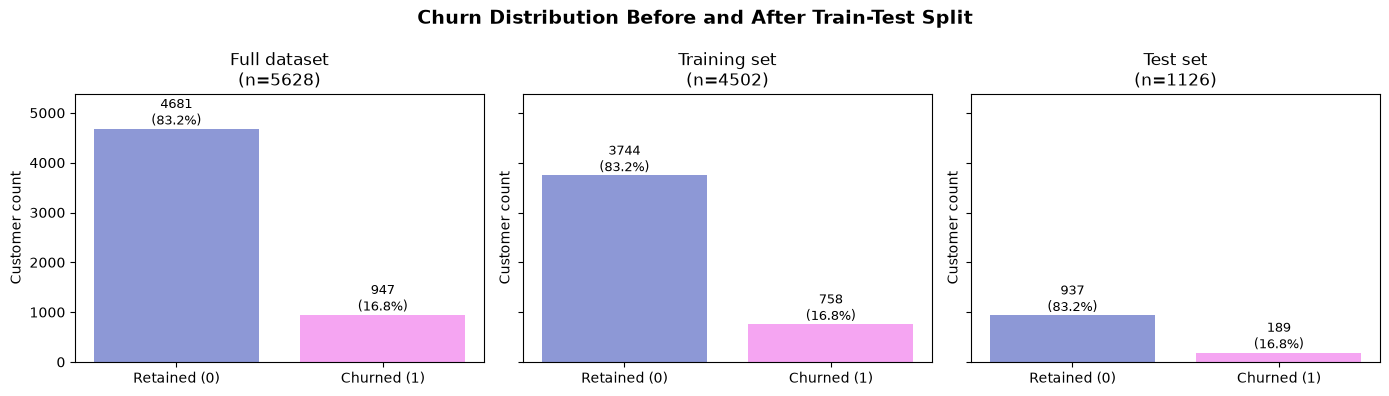

In [126]:
# Split the data into training and test sets while preserving the churn distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature matrix shape:", X_train.shape)
print("Test feature matrix shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

# Check that the churn distribution is preserved after the split
split_distribution = pd.DataFrame({
    "Full dataset (%)": y.value_counts(normalize=True).sort_index() * 100,
    "Training set (%)": y_train.value_counts(normalize=True).sort_index() * 100,
    "Test set (%)": y_test.value_counts(normalize=True).sort_index() * 100
}).round(2)

split_distribution

# Visualize churn distribution before and after the train-test split
split_targets = {
    "Full dataset": y,
    "Training set": y_train,
    "Test set": y_test
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

colors = ["#8D98D6", "#F5A5F2"]
labels = ["Retained (0)", "Churned (1)"]

for ax, (title, target_values) in zip(axes, split_targets.items()):
    counts = target_values.value_counts().reindex([0, 1], fill_value=0)
    percentages = target_values.value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100

    bars = ax.bar(labels, counts.values, color=colors)

    ax.set_title(f"{title}\n(n={len(target_values)})")
    ax.set_ylabel("Customer count")
    ax.set_ylim(0, max(y.value_counts()) * 1.15)

    for bar, count, percentage in zip(bars, counts.values, percentages.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.suptitle("Churn Distribution Before and After Train-Test Split", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The visual check confirms that the stratified split preserved the churn distribution across the full dataset, the training set and the test set. Churned customers remain around 16.8% in each subset, while retained customers remain around 83.2%.

This is important because the test set still reflects the real business setting of the platform: most customers are retained, but the minority churn group is the strategic target of the propensity model. The model will therefore be evaluated on a realistic customer distribution rather than on an artificially balanced sample.

## **Preprocessing Pipeline**

Before defining the preprocessing pipeline, the outlier strategy is connected to the previous data quality audit. Clearly invalid values, such as the unrealistic CashbackAmount values, were already corrected and treated as missing during the cleaning phase.  
The IQR-based outlier analysis was then used as a diagnostic step rather than as an automatic removal rule.  
The remaining extreme values are retained because they may represent meaningful customer behaviors. For instance, high OrderCount or CouponUsed values may indicate highly active or promotion-sensitive customers, high WarehouseToHome values may describe customers living far from the warehouse and long Tenure value may represent loyal customers. For this reason, no additional aggressive clipping is applied at this stage.

The preprocessing pipeline therefore focuses on handling missing values, scaling continuous numerical variables and encoding categorical variables. 
Binary and ordinal numerical variables are kept on their original scale to preserve their business interpretation. All transformations are fitted only on the training data and then applied to the test data, preventing data leakage.

### Preprocessing Strategy Summary

| Feature group                          | Columns                                                                                                                                                                                                                               | Missing value handling                    | Encoding       | Scaling        | Rationale                                                                                                                                                                                                                                                             |
| -------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------- | -------------- | -------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Target variable                        | `Churn`                                                                                                                                                                                                                               | Not applicable                            | Not applicable | Not applicable | Separated from the predictors and used only as the variable to predict.                                                                                                                                                                                               |
| Identifier                             | `CustomerID`                                                                                                                                                                                                                          | Not applicable                            | Not applicable | Not applicable | Removed from the feature matrix because it is a technical identifier and has no behavioral meaning.                                                                                                                                                                   |
| Continuous numerical variables         | `Tenure`, `WarehouseToHome`, `HourSpendOnApp`, `NumberOfDeviceRegistered`, `NumberOfAddress`, `OrderAmountHikeFromlastYear`, `CouponUsed`, `OrderCount`, `DaySinceLastOrder`, `CashbackAmount`, `CouponUsageRate`, `CashbackPerOrder` | Median imputation                         | No encoding    | StandardScaler | These variables describe relationship maturity, engagement, logistics, purchase behavior and monetary reward exposure. Median imputation is robust to skewness and plausible outliers, while scaling makes continuous features comparable for scale-sensitive models. |
| Binary and ordinal numerical variables | `Complain`, `SatisfactionScore`, `CityTier` | Most frequent imputation | No encoding | No scaling | These variables are already numerical and have interpretable discrete meanings. Most frequent imputation preserves their categorical/ordinal nature, while keeping them on their original scale preserves the interpretation of complaints, satisfaction levels and city-tier segmentation. |                                                  |
| Original categorical variables         | `PreferredLoginDevice`, `PreferredPaymentMode`, `PreferredOrderCat`, `Gender`, `MaritalStatus`                                                                                                                                        | Most frequent imputation                  | OneHotEncoder  | No scaling     | These variables have no natural numerical order, so one-hot encoding converts them into model-readable binary indicators.                                                                                                                                             |
| Engineered categorical variables        | `TenureGroup`, `DaysSinceLastOrderGroup`, `ExperienceRiskSegment`, `DeviceCountGroup`, `DeviceComplaintSegment`                                                                                    | Most frequent imputation as a safety step | OneHotEncoder  | No scaling     | These features translate EDA insights into interpretable customer-level segments. Missing values were already handled through explicit “Unknown” categories where needed, so the imputer mainly acts as a safeguard for future or unexpected missing values.          |


In [127]:
# Continuous numerical variables: imputation + scaling
continuous_numeric_features = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
    "CouponUsageRate",
    "CashbackPerOrder"
]

# Binary and ordinal numerical variables: imputation only, no scaling
binary_ordinal_features = [
    "Complain",
    "SatisfactionScore",
    "CityTier"
]

# Categorical variables: imputation + one-hot encoding
categorical_features = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "PreferredOrderCat",
    "Gender",
    "MaritalStatus",
    "TenureGroup",
    "DaysSinceLastOrderGroup",
    "ExperienceRiskSegment",
    "DeviceComplaintSegment"
]

# Check that all columns in X_train are covered by the preprocessing strategy
selected_features = (
    continuous_numeric_features
    + binary_ordinal_features
    + categorical_features
)

missing_from_strategy = set(X_train.columns) - set(selected_features)
extra_in_strategy = set(selected_features) - set(X_train.columns)

print("Columns in X_train not assigned to any preprocessing group:")
print(missing_from_strategy)

print("\nColumns listed in the strategy but not found in X_train:")
print(extra_in_strategy)

# Continuous numerical preprocessing:
# median imputation is robust to skewness and plausible outliers;
# StandardScaler makes continuous variables comparable for scale-sensitive models.
continuous_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Binary and ordinal numerical preprocessing:
# most frequent imputation preserves the discrete meaning of these variables;
# no scaling is applied because the original scale is interpretable.
binary_ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Categorical preprocessing:
# missing categories are imputed first, then one-hot encoded for model compatibility.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine all preprocessing steps into one ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("continuous_num", continuous_numeric_transformer, continuous_numeric_features),
        ("binary_ordinal", binary_ordinal_transformer, binary_ordinal_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("\nPreprocessing pipeline created successfully.")

Columns in X_train not assigned to any preprocessing group:
set()

Columns listed in the strategy but not found in X_train:
set()

Preprocessing pipeline created successfully.


The preprocessing pipeline was successfully created and all predictors were assigned to a preprocessing group. Continuous numerical variables will be imputed and scaled, binary and ordinal variables will be imputed while preserving their original scale and categorical variables will be imputed and one-hot encoded. The empty set outputs confirm that no feature was accidentally excluded from the preprocessing strategy.

In [128]:
# Diagnostic preprocessing check only
# These transformed matrices are used only to verify the preprocessing output
# and will not be used for model training or hyperparameter tuning.
diagnostic_preprocessor = clone(preprocessor)

X_train_preprocessed_check = diagnostic_preprocessor.fit_transform(X_train)
X_test_preprocessed_check = diagnostic_preprocessor.transform(X_test)

print(
    "Diagnostic preprocessed training matrix shape:",
    X_train_preprocessed_check.shape
)

print(
    "Diagnostic preprocessed test matrix shape:",
    X_test_preprocessed_check.shape
)

# Inspect the names of the transformed features for diagnostic purposes
diagnostic_feature_names = (
    diagnostic_preprocessor.get_feature_names_out()
)

print(
    "\nNumber of diagnostic features after preprocessing:",
    len(diagnostic_feature_names)
)

print("\nFirst 20 diagnostic transformed feature names:")
print(diagnostic_feature_names[:20])

Diagnostic preprocessed training matrix shape: (4502, 51)
Diagnostic preprocessed test matrix shape: (1126, 51)

Number of diagnostic features after preprocessing: 51

First 20 diagnostic transformed feature names:
['continuous_num__Tenure' 'continuous_num__WarehouseToHome'
 'continuous_num__HourSpendOnApp'
 'continuous_num__NumberOfDeviceRegistered'
 'continuous_num__NumberOfAddress'
 'continuous_num__OrderAmountHikeFromlastYear'
 'continuous_num__CouponUsed' 'continuous_num__OrderCount'
 'continuous_num__DaySinceLastOrder' 'continuous_num__CashbackAmount'
 'continuous_num__CouponUsageRate' 'continuous_num__CashbackPerOrder'
 'binary_ordinal__Complain' 'binary_ordinal__SatisfactionScore'
 'binary_ordinal__CityTier' 'cat__PreferredLoginDevice_Computer'
 'cat__PreferredLoginDevice_Mobile Phone'
 'cat__PreferredPaymentMode_Cash on Delivery'
 'cat__PreferredPaymentMode_Credit Card'
 'cat__PreferredPaymentMode_Debit Card']


The preprocessing check confirms that the transformation was applied successfully: the original 20 predictors were transformed into 51 model-ready features. This increase is expected because one-hot encoding expands categorical variables into multiple binary indicators.

The displayed feature names provide direct evidence that cateogrical variables such as PreferredLoginDevice and PreferredPaymentMode were encoded correctly. Since the preprocessing was fitted on the training set and then applied to the test set, the workflow remains consistent with a leakage-free modeling procedure.

In [129]:
print(
    "NaN in diagnostic training matrix:",
    np.isnan(X_train_preprocessed_check).sum()
)

print(
    "NaN in diagnostic test matrix:",
    np.isnan(X_test_preprocessed_check).sum()
)

NaN in diagnostic training matrix: 0
NaN in diagnostic test matrix: 0


The final preprocessing validation confirms that no missing values remain in either the training or test matrices after transformation. This is an important quality check before modeling, because all algorithms will receive complete numerical inputs.

The dataset is therefore ready for the propensity modeling phase.

## **Modeling and Evaluation Strategy**

The modeling phase implements a churn propensity model. The objective is not only to classify customers as retained or churned, but also to estimate the probability that each customer will churn. These probabilities can then be used to rank customers by risk and support retention prioritization.

Three algorithms are compared: Logistic Regression, Random Forest and XGBoost.  
Logistic Regression is used as an interpretable baseline, Random Forest is used to capture non-linear relationships and interactions and XGBoost is included as a stronger boosting-based model for structured tabular data.

The models will be evaluated after training using Confusion Matrix, F1-score, Recall and Lift. Recall is especially important in a churn prevention context because missing a real churner means that no retention action is activated for a customer who may leave. A false positive is usually less costly, because contacting a loyal customer mainly creates an additional marketing cost.

### **Hyperparameter Tuning Strategy**

Before evaluating the models on the test set, the more flexible algorithms are tuned using cross-validation on the training data only. This prevents the test set from influencing model selection and keeps it as an unbiased final evaluation sample.

The same stratified cross-validation strategy and the same F1-score objective are used for model selection. F1-score is chosen because it balances precision and recall on the churn class, which is more informative than accuracy in an imbalanced churn problem.

| Model               | Tuning approach                   | Main parameters tuned                                                                                   | Reason                                                                                                                           |
| ------------------- | --------------------------------- | ------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| Baseline            | No tuning                         | Not applicable                                                                                          | Used only as a minimum reference point.                                                                                          |
| Logistic Regression | Fixed interpretable configuration | Regularization type, class weighting                                                                    | Used as a simple and interpretable benchmark rather than as the most flexible model.                                             |
| Random Forest       | RandomizedSearchCV                | Number of trees, tree depth, minimum samples for split and leaf, feature sampling, bootstrap            | Randomized search allows a wider exploration of tree configurations without exhaustively testing every possible combination.     |
| XGBoost             | RandomizedSearchCV                | Number of trees, learning rate, tree depth, sampling ratios, child weight and regularization parameters | XGBoost has a wide hyperparameter space, so randomized search allows broader exploration while keeping training time manageable. |

All tuning is performed only on the training set. The test set is not used during model selection and will be used later only for the final comparison of the selected models.


### **Baseline Model**

Before training predictive models, a majority-class baseline is created as a complete preprocessing-model pipeline. The baseline always predicts the most frequent class, which in this dataset is the retained customer class.

Its purpose is not to produce a useful churn model, but to provide a minimum reference point. Because the dataset is imbalanced, a model that always predicts retention can obtain relatively high accuracy while completely failing to identify churners. Recall, F1-score, PR-AUC and lift are therefore required in addition to accuracy.

Including the preprocessing component in the pipeline ensures that all models follow the same input structure and can receive the original customer-level variables directly.

In [130]:
# Dictionary used to store complete fitted pipelines
trained_models = {}

# Majority-class baseline as a complete preprocessing-model pipeline
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", DummyClassifier(strategy="most_frequent"))
])

# Fit the complete pipeline on the raw training data
baseline_pipeline.fit(X_train, y_train)

# Store the fitted pipeline
trained_models["Baseline"] = baseline_pipeline

print("Baseline pipeline trained successfully.")

Baseline pipeline trained successfully.


The baseline pipeline was fitted successfully on the raw training data. Since the classifier always predicts the retained class, its accuracy is expected to be close to the proportion of retained customers in the dataset. However, it cannot identify any churner, so its recall and F1-score for the churn class are expected to be zero.

These results will be verified during the common evaluation stage on the unseen test set.

### **Logistic Regression**

Logistic Regression is used as the first predictive model because it provides a relatively simple and interpretable benchmark for churn propensity estimation. Unlike the majority-class baseline, it uses the available customer characteristics to estimate both a churn label and a churn probability for each customer.

The classifier uses class_weight="balanced" to reduce the effect of class imbalance by assigning greater importance to the minority churn class during training. L2 regularization is applied to limit overfitting and stabilize the model in the presence of multiple encoded predictors.

Logistic Regression is implemented together with the preprocessing transformer in a single pipeline. The pipeline therefore receives the original customer-level variables, learns imputation, scaling and encoding rules from the training data, and then fits the classifier on the transformed representation.

In [131]:
# Initialize Logistic Regression as a complete preprocessing-model pipeline
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(
        penalty="l2",             # L2 regularization
        C=1.0,                    # Default regularization strength
        solver="lbfgs",           # Suitable solver for L2 Logistic Regression
        max_iter=1000,            # Allows sufficient iterations for convergence
        class_weight="balanced",  # Gives more importance to the minority churn class
        random_state=42           # Ensures reproducible results
    ))
])

# Fit the complete pipeline on the raw training data
log_reg_pipeline.fit(X_train, y_train)

# Store the complete fitted pipeline
trained_models["Logistic Regression"] = log_reg_pipeline

print("Logistic Regression pipeline trained successfully.")

Logistic Regression pipeline trained successfully.


The Logistic Regression pipeline was fitted successfully on the raw training data. The preprocessing transformations and the classifier are now contained in a single fitted object, which can be applied directly to unseen customer records without performing manual transformations.

Its predictive performance should not yet be inferred from successful training alone. Accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC and lift will be calculated later on the untouched test set and compared with the baseline and the tree-based models.

### **Random Forest**

Random Forest is introduced after Logistic Regression to test whether a more flexible non-linear model can better capture churn patterns. In this dataset, churn risk may depend on interactions between customer maturity, complaints, registered-device count, satisfaction level and purchasing behaviour. These relationships may be difficult for a linear model to represent.

The model combines multiple decision trees, reducing the instability of an individual tree and allowing non-linear relationships and feature interactions to emerge.

Random Forest is tuned through stratified cross-validation using a complete preprocessing-model pipeline. Imputation, scaling and one-hot encoding are therefore fitted independently inside each training fold, preventing information from the corresponding validation fold from influencing preprocessing.

In [132]:
# Stratified cross-validation preserves the churn ratio in each fold
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Complete Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter search space
# The model__ prefix refers to the classifier inside the pipeline
rf_param_distribution = {
    "model__n_estimators": randint(200, 800),
    "model__max_depth": [None, 8, 12, 16, 20, 25],
    "model__min_samples_split": randint(2, 11),
    "model__min_samples_leaf": randint(1, 6),
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [True]
}

# Randomized search over the complete pipeline
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distribution,
    n_iter=50,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

# Fit on the original training feature matrix
rf_random_search.fit(X_train, y_train)

# The best estimator is already a complete fitted pipeline
best_rf_pipeline = rf_random_search.best_estimator_

# Store the complete pipeline
trained_models["Random Forest"] = best_rf_pipeline

print("Random Forest RandomizedSearch completed successfully.")
print("Best Random Forest parameters:")
print(rf_random_search.best_params_)
print(
    f"Best cross-validated F1-score: "
    f"{rf_random_search.best_score_:.4f}"
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Random Forest RandomizedSearch completed successfully.
Best Random Forest parameters:
{'model__bootstrap': True, 'model__max_depth': 16, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 720}
Best cross-validated F1-score: 0.8850


The RandomizedSearchCV selected a Random Forest configuration with 720 trees, a maximum depth of 16, square-root feature sampling, and the minimum permitted values for node splitting and leaf size. The relatively large number of trees supports prediction stability, while the depth constraint limits the complexity of each individual tree.

The selected max_features="sqrt" setting introduces diversity across the trees by allowing each split to consider only a subset of the available predictors. At the same time, min_samples_split=2 and min_samples_leaf=1 allow the model to capture relatively detailed customer patterns, with maximum depth acting as the main control against excessive tree growth.

The best cross-validated F1-score is 0.8850. This indicates strong performance in balancing precision and recall for the churn class across the training folds. Because preprocessing was included inside the pipeline, imputation, scaling and encoding were fitted independently within each cross-validation training fold.

This score represents model-development performance rather than final generalization performance. The complete selected pipeline will therefore be evaluated on the untouched test set before drawing conclusions about its suitability for customer-retention targeting.

### **XGBoost**

XGBoost is included as a boosting-based model for structured customer data. Unlike Random Forest, which builds trees largely independently, XGBoost constructs trees sequentially, with each new tree attempting to correct errors made by the preceding ensemble.

The imbalance between retained and churned customers is addressed through scale_pos_weight, calculated from the class distribution in the training set. This gives greater importance to errors involving the minority churn class.

As with Random Forest, XGBoost is tuned through a complete preprocessing-model pipeline. The preprocessing transformer is fitted separately within each cross-validation training fold, preventing validation-fold information from influencing imputation, scaling or categorical encoding.

In [133]:
# Compute class imbalance ratio from the training target only
scale_pos_weight = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)

# Complete XGBoost pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,
        tree_method="hist"
    ))
])

# Hyperparameter search space
# The model__ prefix refers to XGBoost inside the pipeline
xgb_param_distribution = {
    "model__n_estimators": randint(200, 700),
    "model__learning_rate": uniform(0.01, 0.14),
    "model__max_depth": randint(3, 8),
    "model__subsample": uniform(0.7, 0.3),
    "model__colsample_bytree": uniform(0.7, 0.3),
    "model__min_child_weight": randint(1, 8),
    "model__gamma": uniform(0, 0.5),
    "model__reg_lambda": uniform(0.5, 4.5)
}

# Randomized search over the complete pipeline
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_distribution,
    n_iter=50,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

# Fit on the original training feature matrix
xgb_random_search.fit(X_train, y_train)

# The best estimator is already a complete fitted pipeline
best_xgb_pipeline = xgb_random_search.best_estimator_

# Store the complete pipeline
trained_models["XGBoost"] = best_xgb_pipeline

print("XGBoost RandomizedSearch completed successfully.")
print("Best XGBoost parameters:")
print(xgb_random_search.best_params_)
print(
    f"Best cross-validated F1-score: "
    f"{xgb_random_search.best_score_:.4f}"
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
XGBoost RandomizedSearch completed successfully.
Best XGBoost parameters:
{'model__colsample_bytree': np.float64(0.9133448597314053), 'model__gamma': np.float64(0.4047505230698577), 'model__learning_rate': np.float64(0.05881323822084212), 'model__max_depth': 6, 'model__min_child_weight': 1, 'model__n_estimators': 616, 'model__reg_lambda': np.float64(2.2890740948938504), 'model__subsample': np.float64(0.855325405158244)}
Best cross-validated F1-score: 0.8914


The XGBoost RandomizedSearchCV achieved a best cross-validated F1-score of 0.8914. The selected configuration uses a learning rate of approximately 0.11 and a maximum tree depth of 6, allowing the boosting process to capture non-linear customer patterns while controlling the contribution of each successive tree.

The selected column-sampling value of approximately 0.78 means that each tree is trained using only part of the available feature set, which can reduce dependence on individual predictors and improve generalization. A minimum child weight of 5 and a positive gamma value of approximately 0.27 introduce additional constraints on tree growth, requiring new splits to provide sufficient improvement before they are retained.

As with Random Forest, the reported score was obtained using the complete preprocessing-model pipeline within stratified cross-validation. This ensures that imputation, scaling and categorical encoding were learned only from the training portion of each fold.

XGBoost slightly exceeds the Random Forest cross-validated F1-score, with 0.8914 compared with 0.8850. However, the difference is only 0.0.006 and is too small to establish a meaningful advantage at this stage. Final model selection should therefore be based on performance on the untouched test set, together with ranking quality, recall, precision and lift from a retention-campaign perspective.

### **Cross-Validated Model Selection**
The candidate models are compared using F1-scores obtained exclusively from stratified cross-validation on the training set. Because each estimator is stored as a complete preprocessing-model pipeline, imputation, scaling and one-hot encoding are fitted independently within every training fold. The comparison therefore avoids using information from either the validation folds or the untouched test set during model selection.

In [134]:
# Rebuild the dictionary of complete fitted pipelines
# This avoids losing models if trained_models was reset by rerunning the baseline cell
trained_models = {
    "Baseline": baseline_pipeline,
    "Logistic Regression": log_reg_pipeline,
    "Random Forest": best_rf_pipeline,
    "XGBoost": best_xgb_pipeline
}

print("Models currently available:")
print(list(trained_models.keys()))

# Logistic Regression was not tuned, so its CV F1-score is computed here
log_reg_cv_scores = cross_val_score(
    clone(log_reg_pipeline),
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1
)

# Random Forest and XGBoost scores come from their RandomizedSearchCV objects
model_cv_summary = pd.DataFrame(
    {
        "Mean CV F1": {
            "Logistic Regression": log_reg_cv_scores.mean(),
            "Random Forest": rf_random_search.best_score_,
            "XGBoost": xgb_random_search.best_score_
        }
    }
).sort_values(
    by="Mean CV F1",
    ascending=False
)

# Select the final model using training cross-validation only
best_model_name = model_cv_summary["Mean CV F1"].idxmax()
best_model_pipeline = trained_models[best_model_name]

print("\nCross-validated model comparison:")
display(model_cv_summary.round(4))

print(
    f"\nSelected model based on training CV F1-score: "
    f"{best_model_name}"
)

Models currently available:
['Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost']

Cross-validated model comparison:


,Mean CV F1
XGBoost,0.891
Random Forest,0.885
Logistic Regression,0.608



Selected model based on training CV F1-score: XGBoost


XGBoost achieves the highest mean cross-validated F1-score, equal to approximately 0.891. Random Forest follows closely with 0.885, while Logistic Regression obtains a substantially lower score of 0.608. The limited gap between XGBoost and Random Forest indicates that both tree-based models capture the churn patterns effectively, whereas the linear structure of Logistic Regression is less able to represent the non-linear relationships and interactions present in the customer data.

Based on the training cross-validation results, XGBoost is selected as the final candidate model. However, the difference from Random Forest is relatively small, so the selection should not be interpreted as proof of a large performance advantage. The next section evaluates all fitted models on the untouched test set to assess their generalization, probability-ranking quality and usefulness for retention targeting.

## **Final Model Evaluation on Test Set**

The candidate pipelines are now evaluated on the untouched test set using the default classification threshold. This comparison measures both class-level performance and probability-ranking quality. Particular attention is given to recall, F1-score and PR-AUC because churners represent the minority class and are the customers the retention campaign needs to identify.

In [135]:
# Dictionaries used to store final test results and predictions
model_results = {}
model_predictions = {}

# Evaluate all complete fitted pipelines on the untouched test set
for model_name, model in trained_models.items():

    # Complete pipelines receive the original, unprocessed test feature matrix
    y_pred = model.predict(X_test)

    # Predicted probability of Churn = 1
    y_proba = model.predict_proba(X_test)[:, 1]

    # Store predictions for later analyses
    model_predictions[model_name] = {
        "y_pred": y_pred,
        "y_proba": y_proba
    }

    # Store test metrics at the default classification threshold
    model_results[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba)
    }

# Display final model comparison at the default threshold
model_comparison = (
    pd.DataFrame(model_results)
    .T
    .sort_values(by="F1-score", ascending=False)
)

model_comparison.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
XGBoost,0.987,0.939,0.984,0.961,0.999,0.995
Random Forest,0.979,0.899,0.984,0.939,0.998,0.992
Logistic Regression,0.799,0.448,0.847,0.586,0.895,0.712
Baseline,0.832,0.000,0.000,0.000,0.500,0.168


XGBoost provides the strongest overall test performance, reaching an F1-score of **0.961**, a recall of **0.984** and a PR-AUC of **0.995**. Random Forest also performs strongly, with the same recall but a lower precision and F1-score. Logistic Regression captures a substantial share of churners, but its much lower precision indicates that it would generate a considerably larger number of unnecessary contacts.

The baseline confirms why accuracy alone would be misleading: predicting every customer as retained produces an accuracy of **0.832**, while identifying no churners at all. The ensemble models therefore add substantial value beyond the majority-class benchmark, with XGBoost offering the best balance between churn detection and campaign efficiency.

### **Precision Recall Curve**

The Precision–Recall curve evaluates how effectively each model identifies churners across different decision thresholds. It is particularly informative in this setting because the churn class accounts for only **16.8%** of the test population, making a high PR-AUC more meaningful than accuracy alone.

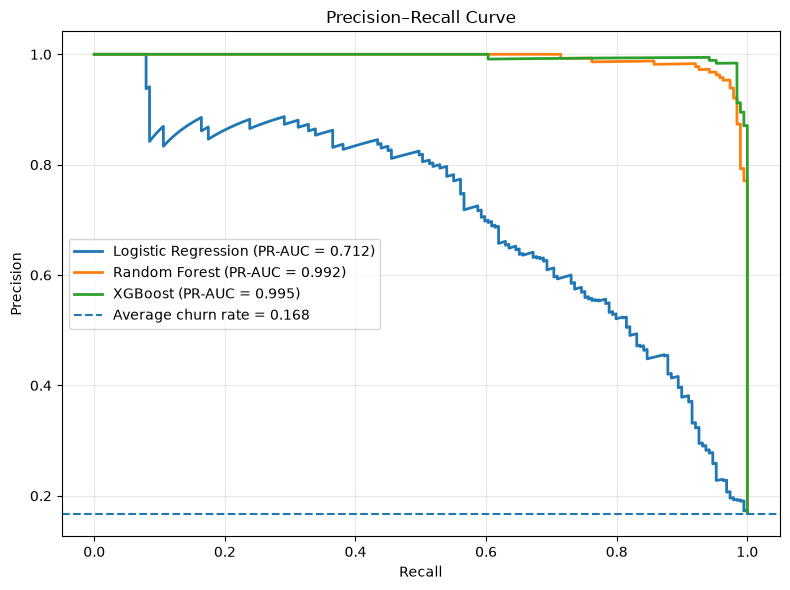

In [136]:
# Baseline churn prevalence in the test set
baseline_churn_rate = y_test.mean()

plt.figure(figsize=(8, 6))

# Plot Precision-Recall curves for predictive models
for model_name, predictions in model_predictions.items():

    # The majority-class baseline is represented by the prevalence line
    if model_name == "Baseline":
        continue

    y_proba = predictions["y_proba"]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_proba
    )

    pr_auc = average_precision_score(
        y_test,
        y_proba
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (PR-AUC = {pr_auc:.3f})"
    )

# Reference performance of random ranking
plt.axhline(
    y=baseline_churn_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Average churn rate = {baseline_churn_rate:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

XGBoost and Random Forest maintain very high precision across almost the entire recall range, with PR-AUC values of **0.995** and **0.992**, respectively. XGBoost retains a small but consistent advantage, while Logistic Regression declines more rapidly as recall increases and reaches a PR-AUC of only **0.712**.

Both ensemble models perform far above the random-ranking reference of **0.168**, confirming that their probability scores can support not only binary classification but also reliable customer prioritisation.

### **Threshold Analysis**

The decision threshold is selected using out-of-fold probabilities generated exclusively from the training data. Each customer therefore receives a churn probability from a pipeline that was not trained on that observation. This prevents the test set from influencing the operational classification rule.

Selected model: XGBoost
Best threshold from training out-of-fold predictions: 0.49
Out-of-fold precision at selected threshold: 0.875
Out-of-fold recall at selected threshold: 0.909
Out-of-fold F1-score at selected threshold: 0.892


,Threshold,Precision,Recall,F1-score,Targeted customers,Targeted share
0,0.300,0.802,0.938,0.864,887,0.197
1,0.400,0.845,0.921,0.881,826,0.183
2,0.490,0.875,0.909,0.892,787,0.175
3,0.500,0.877,0.905,0.891,782,0.174
4,0.600,0.896,0.872,0.884,738,0.164
5,0.700,0.911,0.834,0.871,694,0.154


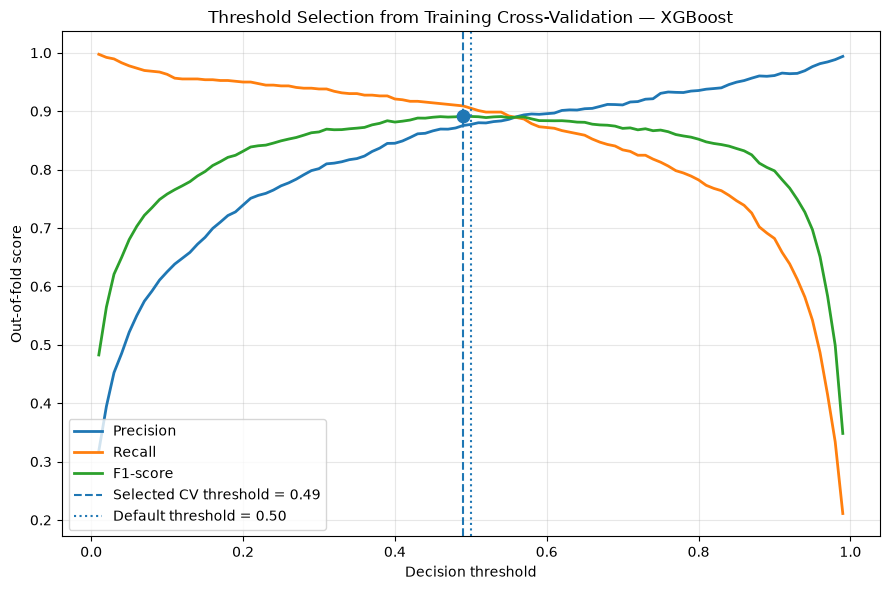

In [137]:
# Generate out-of-fold probabilities on the training set
# The complete pipeline is fitted independently inside each CV fold
y_train_oof_proba = cross_val_predict(
    clone(best_model_pipeline),
    X_train,
    y_train,
    cv=cv_strategy,
    method="predict_proba",
    n_jobs=1
)[:, 1]

# Candidate decision thresholds
thresholds = np.arange(0.01, 1.00, 0.01)

threshold_cv_results = []

for threshold in thresholds:

    y_train_pred_threshold = (
        y_train_oof_proba >= threshold
    ).astype(int)

    threshold_cv_results.append(
        {
            "Threshold": threshold,
            "Precision": precision_score(
                y_train,
                y_train_pred_threshold,
                zero_division=0
            ),
            "Recall": recall_score(
                y_train,
                y_train_pred_threshold,
                zero_division=0
            ),
            "F1-score": f1_score(
                y_train,
                y_train_pred_threshold,
                zero_division=0
            ),
            "Targeted customers": y_train_pred_threshold.sum(),
            "Targeted share": y_train_pred_threshold.mean()
        }
    )

threshold_cv_results = pd.DataFrame(threshold_cv_results)

# Select the threshold with the highest out-of-fold F1-score
# In case of ties, prefer higher precision and then the higher threshold
best_threshold_row = (
    threshold_cv_results
    .sort_values(
        by=["F1-score", "Precision", "Threshold"],
        ascending=[False, False, False]
    )
    .iloc[0]
)

best_threshold = float(best_threshold_row["Threshold"])
best_precision = float(best_threshold_row["Precision"])
best_recall = float(best_threshold_row["Recall"])
best_f1 = float(best_threshold_row["F1-score"])

print(
    f"Selected model: {best_model_name}"
)
print(
    f"Best threshold from training out-of-fold predictions: "
    f"{best_threshold:.2f}"
)
print(
    f"Out-of-fold precision at selected threshold: "
    f"{best_precision:.3f}"
)
print(
    f"Out-of-fold recall at selected threshold: "
    f"{best_recall:.3f}"
)
print(
    f"Out-of-fold F1-score at selected threshold: "
    f"{best_f1:.3f}"
)

# Display a compact comparison of operational thresholds
report_thresholds = sorted(
    set(
        [
            0.30,
            0.40,
            0.50,
            round(best_threshold, 2),
            0.60,
            0.70
        ]
    )
)

threshold_results = []

for threshold in report_thresholds:

    y_train_pred_threshold = (
        y_train_oof_proba >= threshold
    ).astype(int)

    threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": precision_score(
                y_train,
                y_train_pred_threshold,
                zero_division=0
            ),
            "Recall": recall_score(
                y_train,
                y_train_pred_threshold,
                zero_division=0
            ),
            "F1-score": f1_score(
                y_train,
                y_train_pred_threshold,
                zero_division=0
            ),
            "Targeted customers": y_train_pred_threshold.sum(),
            "Targeted share": y_train_pred_threshold.mean()
        }
    )

threshold_results_df = pd.DataFrame(threshold_results)
display(threshold_results_df.round(4))

# Plot threshold behaviour on out-of-fold training predictions
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_cv_results["Threshold"],
    threshold_cv_results["Precision"],
    label="Precision",
    linewidth=2
)

plt.plot(
    threshold_cv_results["Threshold"],
    threshold_cv_results["Recall"],
    label="Recall",
    linewidth=2
)

plt.plot(
    threshold_cv_results["Threshold"],
    threshold_cv_results["F1-score"],
    label="F1-score",
    linewidth=2
)

# Selected threshold
plt.axvline(
    best_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"Selected CV threshold = {best_threshold:.2f}"
)

# Default threshold
plt.axvline(
    0.50,
    linestyle=":",
    linewidth=1.5,
    label="Default threshold = 0.50"
)

plt.scatter(
    best_threshold,
    best_f1,
    s=80,
    zorder=5
)

plt.xlabel("Decision threshold")
plt.ylabel("Out-of-fold score")
plt.title(
    f"Threshold Selection from Training Cross-Validation — "
    f"{best_model_name}"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Retrieve test probabilities only after the threshold has been fixed
y_proba_best = model_predictions[best_model_name]["y_proba"]

In [138]:
threshold_results_df = threshold_results_df.round(4)
threshold_results_df

,Threshold,Precision,Recall,F1-score,Targeted customers,Targeted share
0,0.300,0.802,0.938,0.864,887,0.197
1,0.400,0.845,0.921,0.881,826,0.183
2,0.490,0.875,0.909,0.892,787,0.175
3,0.500,0.877,0.905,0.891,782,0.174
4,0.600,0.896,0.872,0.884,738,0.164
5,0.700,0.911,0.834,0.871,694,0.154


The highest out-of-fold F1-score is obtained at a threshold of **0.49**, with precision of **0.875**, recall of **0.909** and F1-score of **0.892**. The selected value is very close to the default threshold of 0.50, indicating that the XGBoost probabilities are already well aligned with the classification objective and require only a minimal adjustment.

At 0.49, the training cross-validation results classify approximately **17.5%** of customers as retention targets. The threshold is fixed at this stage and is subsequently applied to the untouched test set without further optimisation.

### **Churn Propensity Score Distribution**

The distribution below compares the predicted churn probabilities of retained and churned customers in the test set. It shows whether the final model produces a meaningful risk ranking rather than only assigning binary labels.

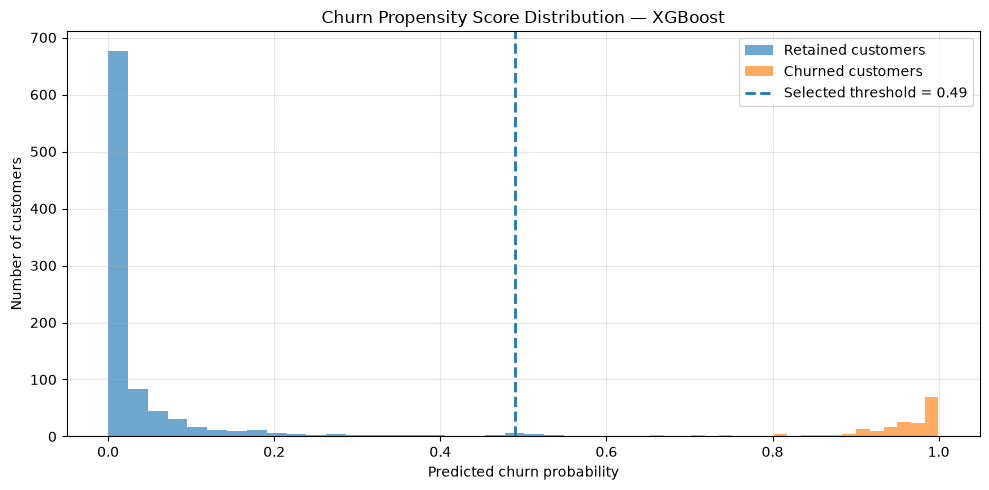

In [139]:
# Test-set churn propensity distribution for the selected final model
propensity_df = pd.DataFrame(
    {
        "actual_churn": y_test.to_numpy(),
        "churn_probability": y_proba_best
    }
)

plt.figure(figsize=(10, 5))

plt.hist(
    propensity_df.loc[
        propensity_df["actual_churn"] == 0,
        "churn_probability"
    ],
    bins=40,
    alpha=0.65,
    label="Retained customers"
)

plt.hist(
    propensity_df.loc[
        propensity_df["actual_churn"] == 1,
        "churn_probability"
    ],
    bins=40,
    alpha=0.65,
    label="Churned customers"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Selected threshold = {best_threshold:.2f}"
)

plt.xlabel("Predicted churn probability")
plt.ylabel("Number of customers")
plt.title(
    f"Churn Propensity Score Distribution — {best_model_name}"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The two classes are strongly separated. Most retained customers receive probabilities close to zero, while most churned customers are concentrated near one. Only a limited number of observations fall close to the selected threshold of **0.49**.

From a marketing perspective, this separation supports differentiated treatment intensity. Customers at the highest end of the score distribution can receive immediate retention actions, while customers with very low scores can remain in standard communication flows without costly incentives.

### **Confusion Matrix**

The cross-validated threshold of 0.49 is now applied once to the untouched test set. The confusion matrix translates model performance into the four operational outcomes that determine the size and efficiency of the retention campaign.

Classification Report — XGBoost at Selected Threshold = 0.49
              precision    recall  f1-score   support

Retained (0)       1.00      0.99      0.99       937
 Churned (1)       0.93      0.98      0.96       189

    accuracy                           0.98      1126
   macro avg       0.96      0.98      0.97      1126
weighted avg       0.99      0.98      0.99      1126



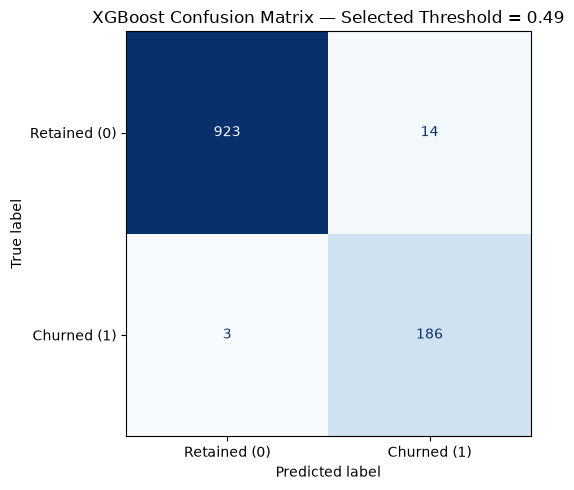

True Negatives (correctly retained): 923
False Positives (retained but targeted): 14
False Negatives (churners missed): 3
True Positives (churners correctly targeted): 186


Threshold              0.490
Accuracy               0.985
Precision              0.930
Recall                 0.984
F1-score               0.956
ROC-AUC                0.999
PR-AUC                 0.995
Targeted customers   200.000
Targeted share         0.178
Name: XGBoost, dtype: float64

In [140]:
# Apply the CV-selected threshold to the untouched test probabilities
y_pred_selected = (
    y_proba_best >= best_threshold
).astype(int)

# Classification report
print(
    f"Classification Report — {best_model_name} "
    f"at Selected Threshold = {best_threshold:.2f}"
)

print(
    classification_report(
        y_test,
        y_pred_selected,
        target_names=["Retained (0)", "Churned (1)"],
        zero_division=0
    )
)

# Confusion matrix
cm_selected = confusion_matrix(
    y_test,
    y_pred_selected
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_selected,
    display_labels=["Retained (0)", "Churned (1)"]
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    f"{best_model_name} Confusion Matrix — "
    f"Selected Threshold = {best_threshold:.2f}"
)

plt.tight_layout()
plt.show()

# Extract confusion matrix values
tn, fp, fn, tp = cm_selected.ravel()

print(f"True Negatives (correctly retained): {tn}")
print(f"False Positives (retained but targeted): {fp}")
print(f"False Negatives (churners missed): {fn}")
print(f"True Positives (churners correctly targeted): {tp}")

# Test metrics at the threshold fixed using training CV
selected_threshold_test_metrics = pd.Series(
    {
        "Threshold": best_threshold,
        "Accuracy": accuracy_score(y_test, y_pred_selected),
        "Precision": precision_score(
            y_test,
            y_pred_selected,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_selected,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            y_pred_selected,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_proba_best),
        "PR-AUC": average_precision_score(
            y_test,
            y_proba_best
        ),
        "Targeted customers": y_pred_selected.sum(),
        "Targeted share": y_pred_selected.mean()
    },
    name=best_model_name
)

selected_threshold_test_metrics.round(4)

The final decision rule correctly identifies **186 of the 189 churners**, corresponding to a recall of **98.4%**, while missing only **3**. It classifies **14 retained customers** as at risk, producing a precision of **93.0%**.

Overall, the model selects **200 customers**, equal to **17.8%** of the test population. Of these, 186 are actual churners. This creates a highly concentrated retention list while preserving almost complete coverage of the churn class.

The selected threshold does not maximise performance retrospectively on the test set. Its slightly lower test F1-score than the default threshold is therefore expected and reflects the correct separation between threshold selection and final evaluation.

## **Why Recall Matters**

In churn prevention, recall is a central metric because the cost of a false negative is usually higher than the cost of a false positive. A false negative represents a customer who is likely to leave but receives no retention intervention. This may result in the loss of future purchases and of the commercial relationship already developed with that customer. A false positive, instead, leads to an unnecessary contact or incentive, which creates a cost but does not imply the loss of an actual churner.

Recall should nevertheless not be maximised in isolation. Contacting a very large share of the customer base would increase campaign costs and could expose low-risk customers to unnecessary discounts. The selected threshold therefore balances churn coverage with precision and operational efficiency.

At the cross-validated threshold of **0.49**, XGBoost identifies **186 of 189 churners** in the test set and misses only **3**. At the same time, only **14 retained customers** enter the retention list unnecessarily. The model therefore achieves very high churn coverage without expanding the campaign to a large proportion of the customer base.

## **ROC-AUC and Lift Comparison**

ROC-AUC measures the models’ ability to rank churners above retained customers across all possible thresholds. Lift adds a campaign-oriented interpretation by comparing risk-based targeting with random customer selection.

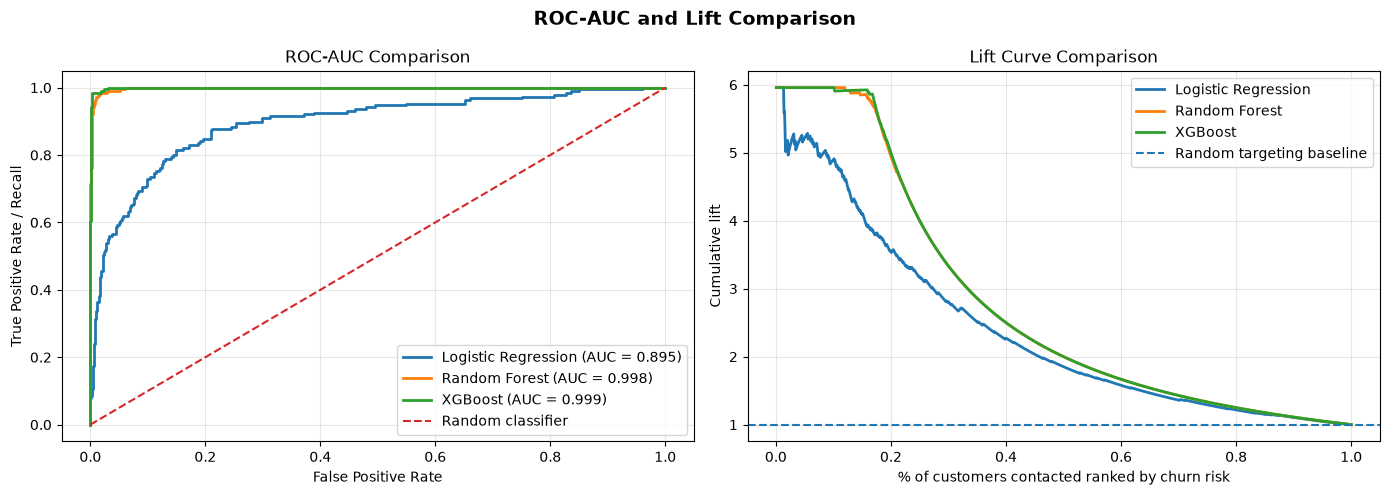

In [141]:
# Function to compute cumulative lift curve
def compute_cumulative_lift(y_true, y_proba):
    lift_data = pd.DataFrame({
        "actual_churn": y_true.values,
        "churn_probability": y_proba
    })
    
    lift_data = lift_data.sort_values(
        by="churn_probability",
        ascending=False
    ).reset_index(drop=True)
    
    lift_data["customer_share"] = (np.arange(1, len(lift_data) + 1)) / len(lift_data)
    lift_data["cumulative_churners"] = lift_data["actual_churn"].cumsum()
    lift_data["cumulative_gain"] = lift_data["cumulative_churners"] / lift_data["actual_churn"].sum()
    lift_data["cumulative_lift"] = lift_data["cumulative_gain"] / lift_data["customer_share"]
    
    return lift_data

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-AUC comparison
for model_name, predictions in model_predictions.items():
    
    if model_name == "Baseline":
        continue
    
    y_proba_model = predictions["y_proba"]
    fpr, tpr, _ = roc_curve(y_test, y_proba_model)
    roc_auc = auc(fpr, tpr)
    
    axes[0].plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.3f})"
    )

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate / Recall")
axes[0].set_title("ROC-AUC Comparison")
axes[0].legend()
axes[0].grid(alpha=0.3)


# Lift curve comparison
for model_name, predictions in model_predictions.items():
    
    if model_name == "Baseline":
        continue
    
    lift_curve = compute_cumulative_lift(y_test, predictions["y_proba"])
    
    axes[1].plot(
        lift_curve["customer_share"],
        lift_curve["cumulative_lift"],
        linewidth=2,
        label=model_name
    )

axes[1].axhline(
    y=1,
    linestyle="--",
    linewidth=1.5,
    label="Random targeting baseline"
)

axes[1].set_xlabel("% of customers contacted ranked by churn risk")
axes[1].set_ylabel("Cumulative lift")
axes[1].set_title("Lift Curve Comparison")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("ROC-AUC and Lift Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

XGBoost achieves the highest ROC-AUC at **0.999**, followed closely by Random Forest at **0.998**. Logistic Regression remains clearly weaker at **0.895**. The very small gap between the two ensemble models confirms that both rank customers effectively, although XGBoost maintains the strongest overall results.

The lift curves show the practical value of this ranking. At low contact shares, XGBoost and Random Forest identify churners at several times the rate expected from random targeting. This concentration allows Marketing to protect most at-risk relationships without distributing retention resources uniformly across the customer base.

## **Lift Analysis**

The following analysis focuses on XGBoost and sorts test customers from the highest to the lowest predicted churn probability. Cumulative gain measures the proportion of all churners captured as the contacted share increases, while cumulative lift compares this result with random targeting.

In [142]:
# Lift Analysis for the selected final model

# Select the final model probabilities
best_model_name = "XGBoost"
y_proba_best = model_predictions[best_model_name]["y_proba"]

# Create a dataframe with true churn labels and predicted churn probabilities
lift_df = pd.DataFrame({
    "actual_churn": y_test.values,
    "churn_probability": y_proba_best
})

# Sort customers from highest to lowest predicted churn risk
lift_df = lift_df.sort_values(
    by="churn_probability",
    ascending=False
).reset_index(drop=True)

# Create deciles: 1 = highest predicted churn risk, 10 = lowest predicted churn risk
lift_df["decile"] = pd.qcut(
    lift_df.index,
    q=10,
    labels=range(1, 11)
)

# Average churn rate in the test set
average_churn_rate = lift_df["actual_churn"].mean()

# Calculate lift table by risk decile
lift_table = (
    lift_df.groupby("decile", observed=True)
    .agg(
        customers=("actual_churn", "count"),
        churners=("actual_churn", "sum"),
        churn_rate=("actual_churn", "mean"),
        avg_probability=("churn_probability", "mean")
    )
    .reset_index()
)

# Decile lift compared with average churn rate
lift_table["lift"] = lift_table["churn_rate"] / average_churn_rate

# Cumulative metrics
lift_table["cumulative_customers"] = lift_table["customers"].cumsum()
lift_table["cumulative_churners"] = lift_table["churners"].cumsum()
lift_table["cumulative_churner_share"] = (
    lift_table["cumulative_churners"] / lift_table["churners"].sum()
)

# Display detailed lift table
lift_table.round(4)

,decile,customers,churners,churn_rate,avg_probability,lift,cumulative_customers,cumulative_churners,cumulative_churner_share
0,1,113,113,1.000,0.984,5.958,113,113,0.598
1,2,113,76,0.673,0.731,4.007,226,189,1.000
2,3,112,0,0.000,0.124,0.000,338,189,1.000
3,4,113,0,0.000,0.038,0.000,451,189,1.000
4,5,112,0,0.000,0.016,0.000,563,189,1.000
5,6,113,0,0.000,0.008,0.000,676,189,1.000
6,7,112,0,0.000,0.004,0.000,788,189,1.000
7,8,113,0,0.000,0.002,0.000,901,189,1.000
8,9,112,0,0.000,0.001,0.000,1013,189,1.000
9,10,113,0,0.000,0.000,0.000,1126,189,1.000


In [143]:
# Business-friendly cumulative lift summary

lift_summary = lift_table.copy()

lift_summary["population_share"] = (
    lift_summary["cumulative_customers"] / lift_summary["customers"].sum()
)

lift_summary["cumulative_gain"] = lift_summary["cumulative_churner_share"]

lift_summary["cumulative_lift"] = (
    lift_summary["cumulative_gain"] / lift_summary["population_share"]
)

lift_summary_display = pd.DataFrame({
    "Top customer share": (lift_summary["population_share"] * 100).round(0).astype(int).astype(str) + "%",
    "Customers contacted": lift_summary["cumulative_customers"],
    "Churners captured": lift_summary["cumulative_churners"],
    "Cumulative gain": (lift_summary["cumulative_gain"] * 100).round(1).astype(str) + "%",
    "Cumulative lift": lift_summary["cumulative_lift"].round(2)
})

lift_summary_display

,Top customer share,Customers contacted,Churners captured,Cumulative gain,Cumulative lift
0,10%,113,113,59.8%,5.960
1,20%,226,189,100.0%,4.980
2,30%,338,189,100.0%,3.330
3,40%,451,189,100.0%,2.500
4,50%,563,189,100.0%,2.000
5,60%,676,189,100.0%,1.670
6,70%,788,189,100.0%,1.430
7,80%,901,189,100.0%,1.250
8,90%,1013,189,100.0%,1.110
9,100%,1126,189,100.0%,1.000


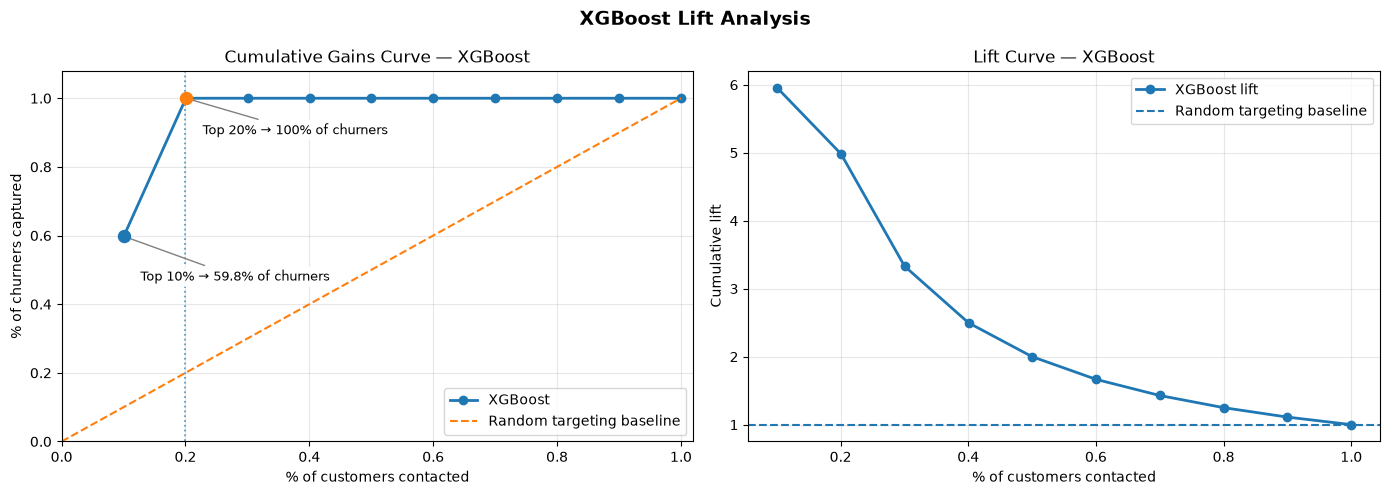

In [144]:
# Plot cumulative gains curve and cumulative lift curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative Gains Curve
axes[0].plot(
    lift_summary["population_share"],
    lift_summary["cumulative_gain"],
    marker="o",
    linewidth=2,
    label="XGBoost"
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random targeting baseline"
)

axes[0].set_xlabel("% of customers contacted")
axes[0].set_ylabel("% of churners captured")
axes[0].set_title("Cumulative Gains Curve — XGBoost")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Annotate only the two most relevant business points
annotation_settings = {
    0.10: {
        "xytext": (12, -24),
        "label": "Top 10% → 59.8% of churners"
    },
    0.20: {
        "xytext": (12, -18),
        "label": "Top 20% → 100% of churners"
    }
}

for share, settings in annotation_settings.items():

    closest_idx = (
        lift_summary["population_share"] - share
    ).abs().idxmin()

    x = lift_summary.loc[closest_idx, "population_share"]
    y = lift_summary.loc[closest_idx, "cumulative_gain"]

    axes[0].scatter(
        x,
        y,
        s=75,
        zorder=4
    )

    axes[0].annotate(
        settings["label"],
        xy=(x, y),
        xytext=settings["xytext"],
        textcoords="offset points",
        fontsize=9,
        ha="left",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.92
        ),
        arrowprops=dict(
            arrowstyle="-",
            linewidth=1,
            color="gray"
        )
    )


# Cumulative Lift Curve
axes[1].plot(
    lift_summary["population_share"],
    lift_summary["cumulative_lift"],
    marker="o",
    linewidth=2,
    label="XGBoost lift"
)

axes[1].axhline(
    y=1,
    linestyle="--",
    linewidth=1.5,
    label="Random targeting baseline"
)

axes[1].set_xlabel("% of customers contacted")
axes[1].set_ylabel("Cumulative lift")
axes[1].set_title("Lift Curve — XGBoost")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[0].axvline(
    x=0.20,
    linestyle=":",
    linewidth=1.3,
    alpha=0.7
)

axes[0].set_xlim(0, 1.02)
axes[0].set_ylim(0, 1.08)

plt.suptitle("XGBoost Lift Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The highest-risk **10%** of customers contains **113 churners**, corresponding to **59.8%** of all churners in the test set and a cumulative lift of **5.96**. In practical terms, the model identifies churners almost six times as efficiently as random targeting within the first decile.

Expanding the contact list to the highest-risk **20%** captures all **189 churners** observed in the test sample, with a cumulative lift of **4.98**. The remaining 80% of customers contains no additional churners in this test split. This result demonstrates the strong concentration achieved by the risk ranking, although its exact magnitude should be validated over future campaign periods before operational deployment.

## **Feature Importance**

XGBoost feature importance provides an initial view of the transformed variables most frequently used to improve the model’s tree splits. Because categorical variables are represented by separate encoded levels, this ranking is interpreted at the transformed-feature level and is followed by SHAP analysis for direction and business-level aggregation.

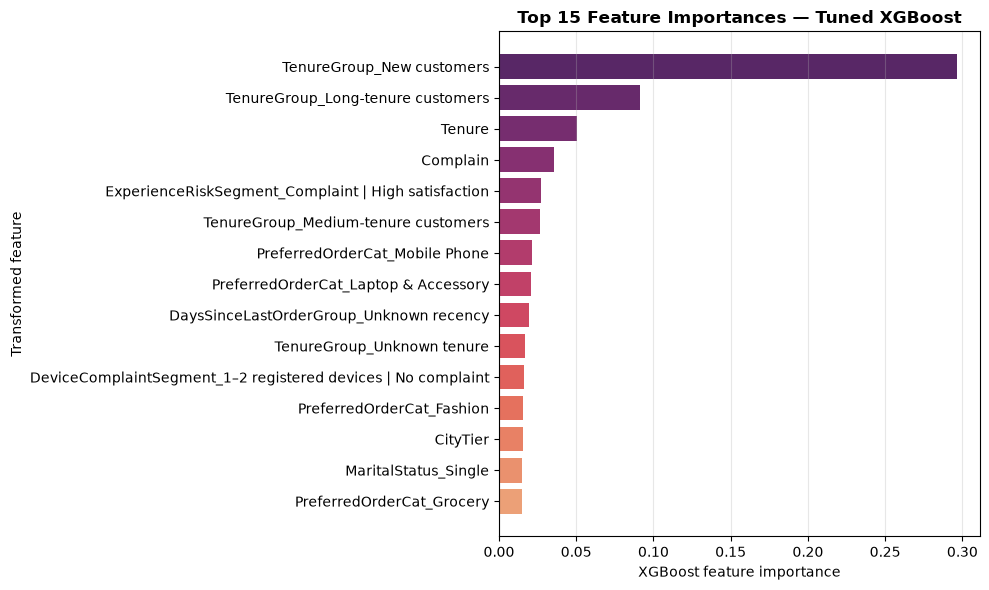

,feature_clean,importance
35,TenureGroup_New customers,0.297
33,TenureGroup_Long-tenure customers,0.091
0,Tenure,0.051
12,Complain,0.036
41,ExperienceRiskSegment_Complaint | High satisfa...,0.027
34,TenureGroup_Medium-tenure customers,0.027
25,PreferredOrderCat_Mobile Phone,0.022
24,PreferredOrderCat_Laptop & Accessory,0.021
40,DaysSinceLastOrderGroup_Unknown recency,0.020
36,TenureGroup_Unknown tenure,0.017


In [145]:
# Retrieve the complete fitted XGBoost pipeline
best_xgb_pipeline = trained_models["XGBoost"]

# Extract the fitted preprocessing transformer and XGBoost classifier
fitted_preprocessor = best_xgb_pipeline.named_steps["preprocessor"]
fitted_xgb_model = best_xgb_pipeline.named_steps["model"]

# Retrieve transformed feature names from the fitted preprocessor
preprocessed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

# Verify that feature names and model inputs have the same length
assert (
    len(preprocessed_feature_names)
    == fitted_xgb_model.n_features_in_
), "Mismatch between transformed feature names and XGBoost input features."

# Create the feature importance dataframe
xgb_importance = pd.DataFrame({
    "feature": preprocessed_feature_names,
    "importance": fitted_xgb_model.feature_importances_
})

# Clean transformed feature names for readability
xgb_importance["feature_clean"] = (
    xgb_importance["feature"]
    .str.replace("continuous_num__", "", regex=False)
    .str.replace("binary_ordinal__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Select and order the top 15 transformed features
top15_importance = (
    xgb_importance
    .nlargest(15, "importance")
    .sort_values("importance")
)

# Create a gradient palette
colors = sns.color_palette(
    "flare",
    len(top15_importance)
)

# Plot the top 15 feature importances
plt.figure(figsize=(10, 6))

plt.barh(
    top15_importance["feature_clean"],
    top15_importance["importance"],
    color=colors
)

plt.xlabel("XGBoost feature importance")
plt.ylabel("Transformed feature")
plt.title(
    "Top 15 Feature Importances — Tuned XGBoost",
    fontweight="bold"
)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Display the underlying values
top15_importance[
    ["feature_clean", "importance"]
].sort_values(
    by="importance",
    ascending=False
).round(4)

The ranking is dominated by customer-tenure information. `TenureGroup_New customers` is the most important transformed feature, with an importance of **0.297**, followed by `TenureGroup_Long-tenure customers` at **0.091** and the continuous `Tenure` variable at **0.051**. The consistent presence of raw and grouped tenure representations confirms that the maturity of the customer relationship is central to churn prediction.

Complaint-related features also appear among the leading predictors. `Complain` reaches an importance of **0.036**, while the segment combining a complaint with high reported satisfaction reaches **0.027**. This supports the earlier observation that a high satisfaction score does not necessarily neutralise the risk associated with an explicit complaint.

The ranking should not be interpreted as a directional or causal explanation. Several entries represent alternative encodings of related information, so SHAP is used next to assess how feature values influence individual predictions and to aggregate them into broader business drivers.

## **SHAP Explainability**

SHAP values explain both the magnitude and direction of each feature’s contribution to the XGBoost predictions. Positive SHAP values push a customer toward the churn class, while negative values reduce the predicted churn risk. Colour represents the original feature value, from low to high.

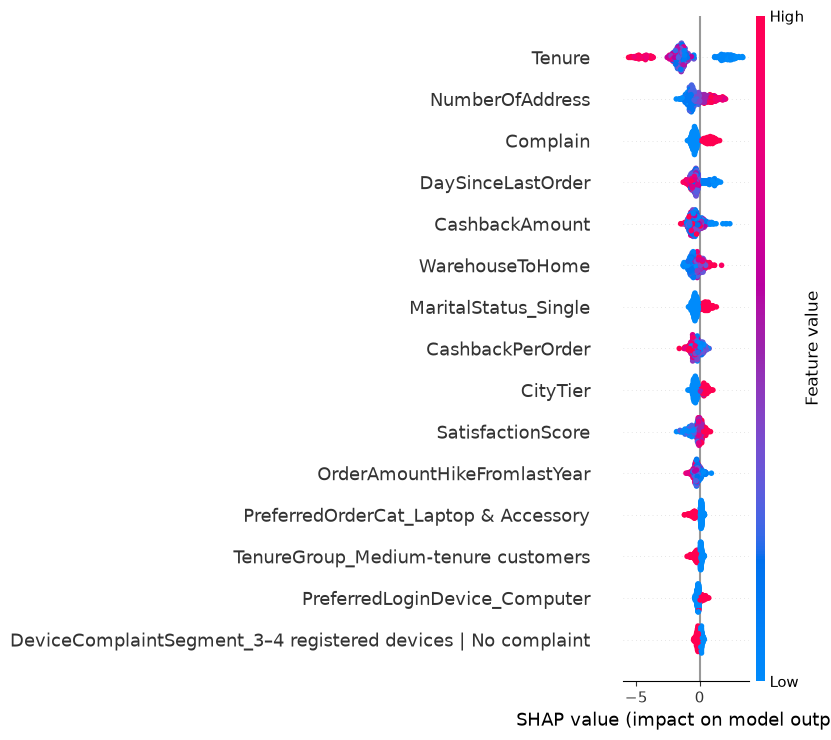

In [146]:
# SHAP Explainability for the final tuned XGBoost model

# Transform the untouched test set using the fitted preprocessing
# transformer contained in the final XGBoost pipeline
X_test_xgb_transformed = fitted_preprocessor.transform(X_test)

# Convert a sparse matrix to a dense array if necessary
if hasattr(X_test_xgb_transformed, "toarray"):
    X_test_xgb_transformed = X_test_xgb_transformed.toarray()

# Create readable transformed feature names
clean_feature_names = (
    pd.Index(preprocessed_feature_names)
    .str.replace("continuous_num__", "", regex=False)
    .str.replace("binary_ordinal__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Create a dataframe for SHAP
X_test_shap = pd.DataFrame(
    X_test_xgb_transformed,
    columns=clean_feature_names,
    index=X_test.index
)

# Use a reproducible sample to keep SHAP computation manageable
X_test_shap_sample = X_test_shap.sample(
    n=min(500, len(X_test_shap)),
    random_state=42
)

# Create the tree-based SHAP explainer
explainer = shap.TreeExplainer(fitted_xgb_model)

# Compute SHAP values
shap_explanation = explainer(X_test_shap_sample)
shap_array = np.asarray(shap_explanation.values)

# Some SHAP versions return an additional class dimension
if shap_array.ndim == 3:
    shap_array = shap_array[:, :, 1]

# SHAP summary plot
shap.summary_plot(
    shap_array,
    X_test_shap_sample,
    max_display=15,
    show=True
)

Tenure produces the widest range of SHAP effects. Lower tenure values are associated with positive contributions to churn risk, while higher tenure values generally move predictions toward retention. This confirms that the earliest stage of the relationship is the most vulnerable period in the customer lifecycle.

Complaint presence also pushes predictions toward churn, while a larger number of addresses and several customer-context variables contribute to smaller but still relevant risk differences. Other features show more mixed patterns, indicating that their effect depends on interactions with the customer’s broader behavioural and experience profile rather than on a simple linear relationship.

## **Top 3 Predictive Drivers of Churn**

To make the explanation suitable for marketing decision-making, related raw, engineered and encoded variables are grouped into broader business families. Their mean absolute SHAP values are then aggregated to measure each family’s share of the total model impact.

In [147]:
# Retrieve transformed feature names from the fitted
# preprocessing component of the final XGBoost pipeline
transformed_feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

# Verify consistency between SHAP values and transformed features
assert shap_array.shape[1] == len(transformed_feature_names), (
    "The number of SHAP columns does not match the number "
    "of transformed feature names."
)

# Original predictors included in the preprocessing pipeline
original_feature_names = (
    continuous_numeric_features
    + binary_ordinal_features
    + categorical_features
)

# Check longer names first to avoid partial matches
# Example: DaysSinceLastOrderGroup before DaySinceLastOrder
original_feature_names_sorted = sorted(
    original_feature_names,
    key=len,
    reverse=True
)


def recover_original_feature(transformed_name):
    """
    Recover the original predictor associated with a transformed feature.

    Examples
    --------
    cat__PreferredPaymentMode_Credit Card
        -> PreferredPaymentMode

    continuous_num__Tenure
        -> Tenure
    """

    clean_name = transformed_name.split("__", 1)[-1]

    for original_name in original_feature_names_sorted:
        if (
            clean_name == original_name
            or clean_name.startswith(original_name + "_")
        ):
            return original_name

    return clean_name


# Map every transformed feature to its original predictor
feature_source_map = {
    transformed_name: recover_original_feature(transformed_name)
    for transformed_name in transformed_feature_names
}

# Group related predictors into business-friendly driver families
business_driver_map = {
    # Relationship lifecycle
    "Tenure": "Relationship maturity",
    "TenureGroup": "Relationship maturity",

    # Purchase timing
    "DaySinceLastOrder": "Purchase recency",
    "DaysSinceLastOrderGroup": "Purchase recency",

    # Customer experience
    "Complain": "Customer experience friction",
    "SatisfactionScore": "Customer experience friction",
    "ExperienceRiskSegment": "Customer experience friction",

    # Device-related complexity and service friction
    "NumberOfDeviceRegistered": "Device-related service friction",
    "DeviceComplaintSegment": "Device-related service friction",

    # Promotional behaviour
    "CouponUsed": "Promotional dependence",
    "CouponUsageRate": "Promotional dependence",

    # Cashback and reward exposure
    "CashbackAmount": "Reward exposure",
    "CashbackPerOrder": "Reward exposure",

    # Purchase activity
    "OrderCount": "Purchase activity",
    "OrderAmountHikeFromlastYear": "Purchase activity",

    # Digital engagement
    "HourSpendOnApp": "Digital engagement",
    "PreferredLoginDevice": "Digital engagement",

    # Logistics and customer-account complexity
    "WarehouseToHome": "Delivery distance",
    "NumberOfAddress": "Address complexity",

    # Commercial preferences
    "PreferredPaymentMode": "Payment preferences",
    "PreferredOrderCat": "Product-category preferences",

    # Customer characteristics
    "Gender": "Customer profile",
    "MaritalStatus": "Customer profile",
    "CityTier": "Customer profile"
}

# Calculate the mean absolute SHAP value of every transformed feature
transformed_shap_importance = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "mean_absolute_shap": np.abs(shap_array).mean(axis=0)
})

# Recover the original predictor behind each transformed column
transformed_shap_importance["original_feature"] = (
    transformed_shap_importance["transformed_feature"]
    .map(feature_source_map)
)

# Assign each original predictor to a business-level driver
transformed_shap_importance["business_driver"] = (
    transformed_shap_importance["original_feature"]
    .map(business_driver_map)
    .fillna(
        transformed_shap_importance["original_feature"]
    )
)

# Aggregate SHAP impact across all features belonging
# to the same business driver
business_driver_importance = (
    transformed_shap_importance
    .groupby("business_driver", as_index=False)
    .agg(
        mean_absolute_shap=(
            "mean_absolute_shap",
            "sum"
        )
    )
    .sort_values(
        by="mean_absolute_shap",
        ascending=False
    )
)

# Convert absolute SHAP impact into percentage share
business_driver_importance["impact_share"] = (
    business_driver_importance["mean_absolute_shap"]
    / business_driver_importance["mean_absolute_shap"].sum()
    * 100
)

# Verify the resulting business-level ranking
business_driver_importance.round(4)

,business_driver,mean_absolute_shap,impact_share
11,Relationship maturity,2.383,24.775
1,Customer experience friction,1.265,13.155
2,Customer profile,1.031,10.723
12,Reward exposure,0.860,8.938
0,Address complexity,0.708,7.360
10,Purchase recency,0.653,6.787
6,Payment preferences,0.523,5.440
7,Product-category preferences,0.481,5.004
4,Device-related service friction,0.471,4.898
3,Delivery distance,0.441,4.588


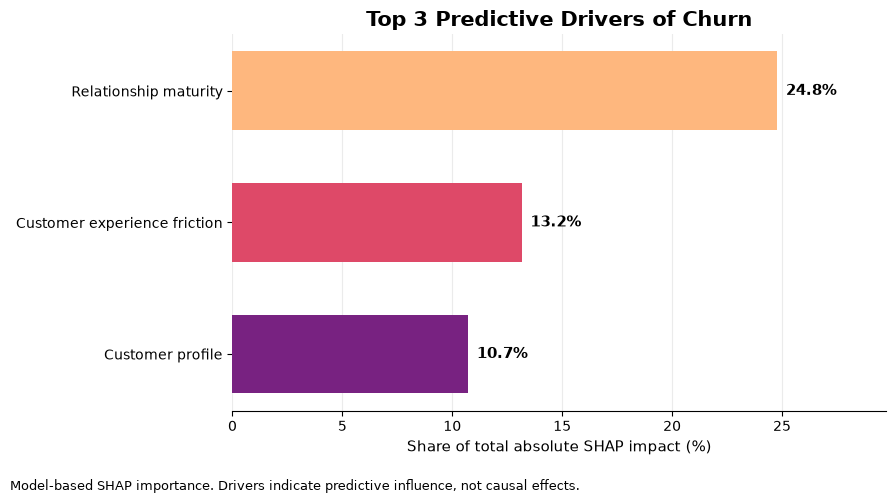

,business_driver,mean_absolute_shap,impact_share
11,Relationship maturity,2.383,24.775
1,Customer experience friction,1.265,13.155
2,Customer profile,1.031,10.723


In [148]:
# Select the top three drivers
top3_business_drivers = (
    business_driver_importance
    .head(3)
    .sort_values("impact_share")
)


fig, ax = plt.subplots(figsize=(9, 5))

# Create 3 different shades from a colormap
cmap = plt.cm.magma
bar_colors = [cmap(0.35), cmap(0.60), cmap(0.85)]

bars = ax.barh(
    top3_business_drivers["business_driver"],
    top3_business_drivers["impact_share"],
    color=bar_colors,
    edgecolor="none",
    height=0.6
)

# Add percentage labels at the end of each bar
for bar, value in zip(bars, top3_business_drivers["impact_share"]):
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )

ax.set_xlabel("Share of total absolute SHAP impact (%)", fontsize=11)
ax.set_ylabel("")
ax.set_title(
    "Top 3 Predictive Drivers of Churn",
    fontsize=15,
    fontweight="bold"
)

ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

ax.set_xlim(
    0,
    top3_business_drivers["impact_share"].max() * 1.20
)

# Clean up spines for a nicer stakeholder-friendly look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.figtext(
    0.01,
    0.01,
    "Model-based SHAP importance. Drivers indicate predictive influence, not causal effects.",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# Display table
top3_business_drivers[
    ["business_driver", "mean_absolute_shap", "impact_share"]
].sort_values(
    by="impact_share",
    ascending=False
).round(4)

**Relationship maturity** is the leading predictive driver, accounting for **24.8%** of total absolute SHAP impact. It substantially exceeds the other business families and confirms that customer vulnerability is strongly concentrated in the early stages of the relationship.

**Customer experience friction** ranks second at **13.2%**, combining complaint, satisfaction and experience-risk information. **Customer profile** contributes a further **10.7%**, reflecting differences associated with variables such as marital status and city tier. Together, the three leading families account for approximately **48.7%** of the model’s total aggregated impact.

These percentages represent predictive influence rather than causal effects. In particular, customer-profile variables should support contextual interpretation and communication personalisation, not exclusionary targeting.

## **Retention Strategy**

The predictive model becomes actionable only when churn risk is connected to an appropriate level of marketing investment. Customers are therefore segmented using two dimensions: their predicted churn probability and a relative value proxy based on order activity and cashback exposure.

The value score is not a financial CLTV estimate. It is used only to distinguish customers who may justify more resource-intensive retention treatment from customers better suited to automated or low-cost communication.

| Churn risk | Customer value proxy | Recommended action | Business logic |
|---|---|---|---|
| High risk | High value | Priority retention | Personal outreach, premium incentive, customer-care follow-up |
| High risk | Low value | Automated retention | Low-cost coupon, email reminder, app notification |
| Medium risk | High value | Preventive nurturing | Loyalty benefits, personalized recommendations, early warning communication |
| Low risk | High value | Relationship protection | VIP communication, satisfaction monitoring, loyalty reinforcement |
| Low risk | Low value | No costly action | Standard newsletter or low-cost automated communication |

In [149]:
# Create an actionability dataset for test customers
strategy_df = X_test.copy()

# Add churn probabilities from the selected final model
strategy_df["churn_probability"] = y_proba_best

# Customer value proxy

value_features = [
    "OrderCount",
    "CashbackAmount"
]

# Median imputation is used only for the post-model strategy score
for feature in value_features:
    strategy_df[f"{feature}_filled"] = (
        strategy_df[feature]
        .fillna(strategy_df[feature].median())
    )

# Percentile ranks provide a more robust normalization than
# min-max scaling when variables contain asymmetric values
strategy_df["OrderCount_rank"] = (
    strategy_df["OrderCount_filled"]
    .rank(method="average", pct=True)
)

strategy_df["CashbackAmount_rank"] = (
    strategy_df["CashbackAmount_filled"]
    .rank(method="average", pct=True)
)

# Equal-weight relative customer-value proxy
strategy_df["customer_value_proxy"] = (
    0.50 * strategy_df["OrderCount_rank"]
    + 0.50 * strategy_df["CashbackAmount_rank"]
)


# Churn-risk segmentation

low_risk_cutoff = 0.30

# Verify that the CV-selected threshold can be used as
# the boundary between medium and high risk
assert best_threshold > low_risk_cutoff, (
    "The selected churn threshold must be greater than "
    "the low-risk cutoff."
)

strategy_df["churn_risk_segment"] = pd.cut(
    strategy_df["churn_probability"],
    bins=[
        -np.inf,
        low_risk_cutoff,
        best_threshold,
        np.inf
    ],
    labels=[
        "Low risk",
        "Medium risk",
        "High risk"
    ],
    include_lowest=True
)

# Relative customer-value segmentation

# The top 25% of the campaign population is classified
# as relatively high value
value_threshold = (
    strategy_df["customer_value_proxy"]
    .quantile(0.75)
)

strategy_df["value_segment"] = np.where(
    strategy_df["customer_value_proxy"] >= value_threshold,
    "High value",
    "Standard value"
)

# Recommended retention actions

def assign_retention_action(row):

    risk = row["churn_risk_segment"]
    value = row["value_segment"]

    if risk == "High risk" and value == "High value":
        return "Priority retention"

    if risk == "High risk" and value == "Standard value":
        return "Automated retention"

    if risk == "Medium risk" and value == "High value":
        return "Preventive nurturing"

    if risk == "Medium risk" and value == "Standard value":
        return "Low-cost nurturing"

    if risk == "Low risk" and value == "High value":
        return "VIP relationship care"

    return "Standard communication"


strategy_df["recommended_action"] = strategy_df.apply(
    assign_retention_action,
    axis=1
)

# Detailed description of each action
action_description = {
    "Priority retention":
        "Personal outreach combined with a premium incentive",

    "Automated retention":
        "Automated email or low-cost coupon",

    "Preventive nurturing":
        "Loyalty benefit or personalised engagement message",

    "Low-cost nurturing":
        "Low-cost reminder or educational communication",

    "VIP relationship care":
        "Recognition, loyalty protection and value reinforcement",

    "Standard communication":
        "Routine communication without costly retention action"
}

strategy_df["action_description"] = (
    strategy_df["recommended_action"]
    .map(action_description)
)


# Strategy summary

strategy_summary = (
    strategy_df
    .groupby(
        [
            "churn_risk_segment",
            "value_segment",
            "recommended_action",
            "action_description"
        ],
        observed=True
    )
    .size()
    .reset_index(name="customers")
)

strategy_summary["customer_share"] = (
    strategy_summary["customers"]
    / len(strategy_df)
    * 100
)

strategy_summary.sort_values(
    by=[
        "churn_risk_segment",
        "value_segment"
    ]
).round(2)

,churn_risk_segment,value_segment,recommended_action,action_description,customers,customer_share
0,Low risk,High value,VIP relationship care,"Recognition, loyalty protection and value rein...",243,21.580
1,Low risk,Standard value,Standard communication,Routine communication without costly retention...,662,58.790
2,Medium risk,High value,Preventive nurturing,Loyalty benefit or personalised engagement mes...,1,0.090
3,Medium risk,Standard value,Low-cost nurturing,Low-cost reminder or educational communication,20,1.780
4,High risk,High value,Priority retention,Personal outreach combined with a premium ince...,38,3.370
5,High risk,Standard value,Automated retention,Automated email or low-cost coupon,162,14.390


The selected threshold identifies **200 high-risk customers**, equal to **17.8%** of the test population. Among them, **38** are classified as relatively high value and receive priority retention treatment, while **162** are assigned to automated retention. These two groups correspond exactly to the final model’s operational target list.

A further **21 customers** fall into the medium-risk segment and receive preventive or low-cost nurturing. Most customers remain low risk: **243 high-value customers** receive relationship-protection communication, while **662 customers** remain in the standard communication flow without costly retention action.

The final allocation quantifies how the risk-and-value framework translates into campaign volumes. It separates intensive retention interventions from scalable automated actions and from routine communication, allowing Marketing to match the cost of each action to the expected customer risk and value.

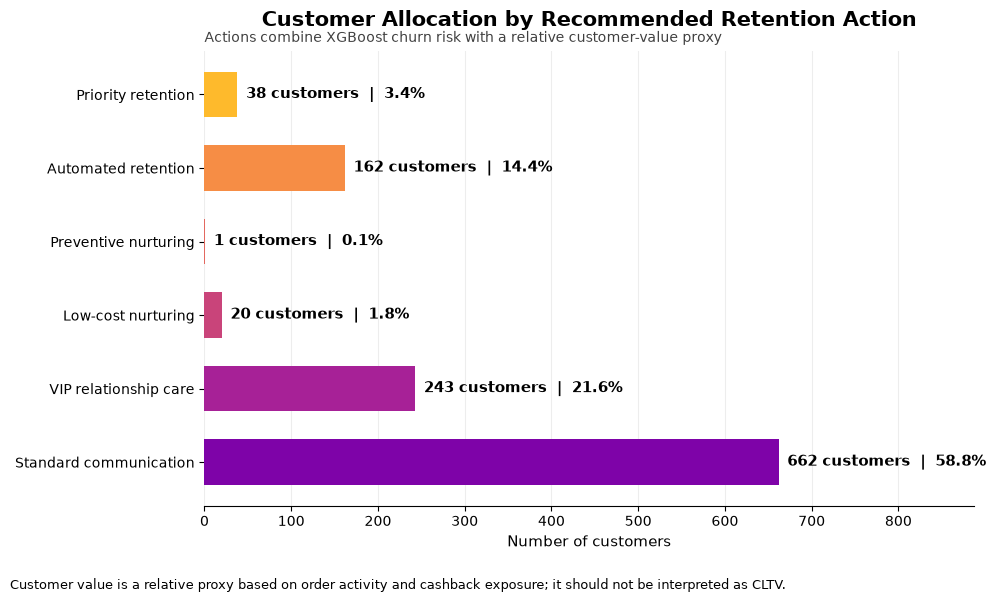

,Recommended action,Customers,Customer share (%)
0,Priority retention,38,3.370
1,Automated retention,162,14.390
2,Preventive nurturing,1,0.090
3,Low-cost nurturing,20,1.780
4,VIP relationship care,243,21.580
5,Standard communication,662,58.790


In [150]:
# Retention Action Allocation Visualization

# Define a meaningful operational order
action_order = [
    "Priority retention",
    "Automated retention",
    "Preventive nurturing",
    "Low-cost nurturing",
    "VIP relationship care",
    "Standard communication"
]

# Count customers assigned to each action
action_counts = (
    strategy_df["recommended_action"]
    .value_counts()
    .reindex(action_order, fill_value=0)
)

# Remove actions with no assigned customers
action_counts = action_counts[action_counts > 0]

# Calculate customer shares
action_shares = (
    action_counts
    / len(strategy_df)
    * 100
)

# Reverse the order so the highest-priority action appears at the top
plot_counts = action_counts.iloc[::-1]
plot_shares = action_shares.iloc[::-1]

# Create different shades from the same gradient palette
cmap = plt.cm.plasma

color_positions = np.linspace(
    0.25,
    0.85,
    len(plot_counts)
)

bar_colors = [
    cmap(position)
    for position in color_positions
]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_counts.index,
    plot_counts.values,
    color=bar_colors,
    edgecolor="none",
    height=0.62
)

# Add count and percentage labels
for bar, count, share in zip(
    bars,
    plot_counts.values,
    plot_shares.values
):
    ax.text(
        bar.get_width() + max(plot_counts.values) * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{count} customers  |  {share:.1f}%",
        va="center",
        ha="left",
        fontsize=10.5,
        fontweight="bold"
    )

ax.set_xlabel("Number of customers", fontsize=11)
ax.set_ylabel("")

ax.set_title(
    "Customer Allocation by Recommended Retention Action",
    fontsize=15,
    fontweight="bold",
    pad=18
)

# Add a short explanatory subtitle
ax.text(
    0,
    1.02,
    (
        f"Actions combine {best_model_name} churn risk "
        f"with a relative customer-value proxy"
    ),
    transform=ax.transAxes,
    fontsize=10,
    alpha=0.75
)

ax.grid(
    axis="x",
    alpha=0.22
)

ax.set_axisbelow(True)

# Leave room for labels outside the bars
ax.set_xlim(
    0,
    max(plot_counts.values) * 1.34
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.figtext(
    0.01,
    0.01,
    (
        "Customer value is a relative proxy based on order activity "
        "and cashback exposure; it should not be interpreted as CLTV."
    ),
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# Display numerical allocation
pd.DataFrame({
    "Recommended action": action_counts.index,
    "Customers": action_counts.values,
    "Customer share (%)": action_shares.values
}).round(2)

Only **3.4%** of customers are assigned to priority personal retention, while **14.4%** receive automated retention. Together, these two high-risk actions cover **200 customers**, or **17.8%** of the test population, and contain **186 of the 189 actual churners**.

Most of the customer base does not require a costly churn intervention. **58.8%** remain in standard communication and **21.6%** receive lower-cost VIP relationship care. The resulting campaign therefore concentrates direct retention resources on a small, high-risk audience while preserving lighter relationship-building actions for valuable customers who are not currently at risk.

## **Deployment**

The final model should be integrated into the retention workflow as a recurring decision-support system rather than used as a one-time analysis. Each scoring cycle should produce a churn probability, a risk tier and a recommended action that can be transferred to the CRM and customer-service teams.

The deployment design therefore separates model scoring from campaign execution. Marketing uses the risk-and-value segmentation to allocate retention resources, while customer service receives alerts for customers requiring personal recovery actions. Model performance and campaign outcomes must then be monitored jointly to verify that predictive accuracy translates into measurable retention impact.

| Deployment phase | Operational process | Business user | Output |
|---|---|---|---|
| Batch scoring | Score active customers weekly or monthly | Marketing team | Churn probability and risk tier |
| Campaign targeting | Select customers by risk tier and value proxy | CRM / Marketing | Retention campaign list |
| Customer service alert | Flag high-risk customers in support dashboard | Customer service team | Priority service recovery |
| Monitoring | Track predictive and campaign performance | Data / Marketing team | Model drift and ROI indicators |
| Retraining | Update model every 3–6 months | Data team | Refreshed churn model |

A weekly or monthly batch-scoring process would be sufficient for this type of customer-level churn model, depending on how frequently the underlying behavioural data are updated. The operational output should include the customer identifier, churn probability, risk segment, value segment and recommended retention action.

Monitoring should not focus only on technical metrics. Recall, precision, score distribution and feature drift should be reviewed together with campaign response, coupon redemption and observed post-campaign retention. Retraining every three to six months provides an initial schedule, but an earlier update should be triggered if customer behaviour or model performance changes materially.

Because relationship maturity is the strongest predictive driver, the missing values in `Tenure` require an additional robustness check. The following comparison tests whether customers with missing tenure behave similarly to customers with a recorded relationship history or whether the missingness itself identifies a distinctive risk group.

In [151]:
# Verify robustness: count + churn rate by Tenure missingness
tenure_missing_summary = df.groupby(df['Tenure'].isna())['Churn'].agg(
    n_customers='count',
    churn_rate='mean'
)
tenure_missing_summary.index = tenure_missing_summary.index.map({False: 'Tenure known', True: 'Tenure missing'})
tenure_missing_summary

,n_customers,churn_rate
Tenure,,
Tenure known,5364,0.161
Tenure missing,264,0.307


Customers with a recorded tenure have an observed churn rate of **16.1%**, while customers with missing tenure reach **30.7%**. The missing-tenure group therefore shows almost twice the churn incidence of customers whose relationship duration is available.

This result supports preserving `Unknown tenure` as a separate category rather than assigning these customers to an ordinary tenure group. However, the pattern should not be interpreted causally. Missing tenure may reflect incomplete customer histories, recent account migration or other data-quality processes that are themselves associated with churn risk.

## **Limitations and Next Steps**

The analysis provides a strong predictive and operational framework, but several limitations remain. The dataset represents a historical customer snapshot and does not contain complete revenue, margin or customer-lifetime-value information. The customer-value score used in the retention strategy is therefore a relative proxy based on order activity and cashback exposure, not a direct estimate of future profitability.

The model also identifies predictive associations rather than causal drivers. SHAP values explain how variables influence model predictions, but they do not prove that changing a feature will reduce churn. Customer-profile variables should consequently be used for contextual interpretation and message personalisation, not as the sole basis for excluding or prioritising customers.

The unusually strong separation observed on the test set should be validated on a later time period before deployment. A temporal validation design would provide a more realistic estimate of performance when the model is applied to future customers and would help detect changes in purchasing behaviour, campaign policies or data collection processes.

The next operational step is to test the proposed retention treatments through controlled experiments. The First 90-Days Shield and complaint-recovery actions should be evaluated through A/B testing against standard communication, measuring incremental retention, campaign cost, coupon redemption and customer value after the intervention. These results can then be used to replace the current rule-based action allocation with an evidence-based campaign policy.